# **Assignment 1**
---
CC4051 Machine Learning - FCUP
---
06.04.2025
---
By Camila Alves, Miguel Goncalves, and Nina Lichtenberger

# 1. Introduction
Machine learning models operate under different assumptions and exhibit distinct behaviors based on dataset characteristics. This project aims to explore and analyze these assumptions by generating artificial datasets that highlight the strengths and weaknesses of various classification models, including Logistic Regression, Linear Discriminant Analysis (LDA), Quadratic Discriminant Analysis (QDA), Decision Trees (with and without pruning), and Support Vector Machines (SVM) with both linear and RBF kernels.

Through controlled experimentation, we will investigate how these models perform under different conditions, such as variations in class distribution, boundary complexity, noise levels, and class overlap. The project is structured around three key objectives:

* **Understanding Model Assumptions** - Identifying datasets that align well with each model's assumptions and where competing models struggle.
* **Bias-Variance Tradeoff & Model Capacity** - Analyzing how dataset properties, particularly noise and decision boundary shape, influence model performance.
* **Ensemble Methods** - Comparing Bagging, Random Forest, and Boosting techniques to evaluate their effectiveness in improving model robustness and accuracy.


The project will be implemented using Python in a Jupyter Notebook, where results will be documented with clear explanations, visualizations, and comparisons. The findings will provide valuable insights into model performance based on dataset characteristics and highlight the practical implications of different learning algorithms.

# 2. Model Testing: Exploring Assumptions and Behavior
In this section, we evaluate the performance of various machine learning models on artificially generated as well as real datasets. Each dataset is designed to highlight the strengths and weaknesses of a specific model by aligning the dataset with the model's assumptions while challenging other model assumptions.

By analyzing classification boundaries, class distributions, and noise levels, we aim to understand when each model performs optimally and when it struggles.

In [ ]:
!pip install ucimlrepo
import pandas as pd
from ucimlrepo import fetch_ucirepo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold,cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from mlxtend.evaluate import bias_variance_decomp
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import random
from sklearn.datasets import make_classification, make_moons
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

## 1. Logistic Regression

Logistic Regression can be used for classification tasks with categorical target variables, modeling the relationship between the predictors and the response variable using the logistic function (Ng & Jordan, 2002). It focuses on the conditional distribution of the response variable, assuming that the log-odds of the outcome are a linear combination of the predictors. Logistic Regression is particularly effective when classes are linearly separable but can struggle when the data distribution is more complex (Ng & Jordan, 2002).

### 1.1 Assumptions of Logistic Regression

The logistic regression has the following assumptions (Ng & Jordan, 2002):

* **Linearity in the Log-Odds**: Logistic regression assumes a linear relationship between the independent variables and the log-odds of the dependent variable.

* **Independence of Observations**: Observations are independent of each other.

* **No Multicollinearity**: There should be minimal multicollinearity among predictors.

### 1.2 Implementation on Artificial Dataset

To generate a dataset optimized for Logistic Regression, the main characteristics of the dataset should be the following:

* **Linearly Separable Features**: Clear linear relationship between independent variables and the log-odds of the outcome
* **Minimal Multicollinearity**: Highly correlated features can distort coefficient estimates
* **Independence of Observations**: Each observation should be unique and not dependent on others to prevent biased parameter estimation
* **Structured Noise**: Highly correlated noise (redunant information) will make non-linear models prone to overfit, ensuring that they are outperformed by the Logistic Regression  

Considering the linear nature of the data, the main competitive models are the LDA and the linear SVM. Given that they have similar model assumptions, it is likely that their performance will be close to the performance of the Logistic Regression.

In [ ]:
np.random.seed(42)

# Generate a dataset optimized for logistic regression
n_samples = 1000
n_features = 5

# Generate features that are truly linearly separable
X = np.random.rand(n_samples, n_features)

# Create a TRUE linear relationship (only useful for logistic regression)
true_coefficients = np.array([3, -2, 1, 2.5, -3])  # Linear effects only
linear_combination = X @ true_coefficients

# Convert to probabilities using the sigmoid function
probabilities = 1 / (1 + np.exp(-linear_combination))
y = (probabilities > 0.5).astype(int)  # Binarizing outcomes

# **Add structured noise to mislead non-linear models**
# Introduce highly correlated noise (redundant info that non-linear models overfit on)
correlated_noise = 0.8 * X + np.random.normal(0, 0.05, X.shape)

# Add completely random irrelevant features
irrelevant_features = np.random.normal(0, 1, (n_samples, 5))

# Stack all features together
X_noisy = np.hstack((X, correlated_noise, irrelevant_features))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

# Standardize features for models sensitive to scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_noisy, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
Logistic Regression: 0.978
Linear SVM: 0.977
LDA: 0.965
QDA: 0.953
RBF SVM: 0.913
Decision Tree: 0.843
Decision Tree (Max Depth=2): 0.781


In [ ]:
for size in [100, 500, 999]:
    X_sub, _, y_sub, _ = train_test_split(X_noisy, y, train_size=size, random_state=42)
    model = LogisticRegression()
    score = cross_val_score(model, X_sub, y_sub, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {size} samples: {score:.3f}")

Accuracy with 100 samples: 0.910
Accuracy with 500 samples: 0.966
Accuracy with 999 samples: 0.973


In [ ]:
y_multi_3 = np.digitize(probabilities, bins=[0.3, 0.6, 0.9])  # Convert to 3 classes
y_multi_4 = np.digitize(probabilities, bins=[0.2, 0.5, 0.7, 0.9])  # Convert to 4 classes

for y_multi, classes in zip([y_multi_3, y_multi_4], [3, 4]):
    model = LogisticRegression(multi_class="multinomial", solver="lbfgs")
    score = cross_val_score(model, X_noisy, y_multi, cv=5, scoring='accuracy').mean()
    print(f"Accuracy for multi-class ({classes} classes): {score:.3f}")

Accuracy for multi-class (3 classes): 0.881
Accuracy for multi-class (4 classes): 0.799


In [ ]:
y_balanced = y  # Original dataset (50-50)
y_imbalanced = np.where(probabilities > 0.8, 1, 0)  # 80% class 1

for y_data, label in zip([y_balanced, y_imbalanced], ["Balanced", "80% Class 1"]):
    model = LogisticRegression()
    score = cross_val_score(model, X_noisy, y_data, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {label} data: {score:.3f}")

Accuracy with Balanced data: 0.978
Accuracy with 80% Class 1 data: 0.973


In [ ]:
X_normal = X  # Original data
X_spread = X + np.random.normal(0, 2, X.shape)  # Increased spread

for X_var, label in zip([X_normal, X_spread], ["Normal", "Spread Out"]):
    X_noisy_var = np.hstack((X_var, correlated_noise, irrelevant_features))
    score = cross_val_score(LogisticRegression(), X_noisy_var, y, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {label} class distribution: {score:.3f}")

Accuracy with Normal class distribution: 0.978
Accuracy with Spread Out class distribution: 0.923


In [ ]:
y_linear = y  # Original binary labels
y_xor = (X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)  # XOR pattern

for y_data, label in zip([y_linear, y_xor], ["Linear", "XOR"]):
    score = cross_val_score(LogisticRegression(), X_noisy, y_data, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {label} decision boundary: {score:.3f}")

Accuracy with Linear decision boundary: 0.978
Accuracy with XOR decision boundary: 0.521


In [ ]:
for noise_level in [0, 0.5, 1.0]:
    X_noisy_test = X + np.random.normal(0, noise_level, X.shape)
    X_noisy_test = np.hstack((X_noisy_test, correlated_noise, irrelevant_features))
    score = cross_val_score(LogisticRegression(), X_noisy_test, y, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with noise level {noise_level}: {score:.3f}")

Accuracy with noise level 0: 0.978
Accuracy with noise level 0.5: 0.927
Accuracy with noise level 1.0: 0.928


In [ ]:
true_coefficients_normal = np.array([3, -2, 1, 2.5, -3])  # Original
true_coefficients_small = np.array([0.5, -0.5, 0.3, 0.4, -0.3])  # Lower weights

for coefs, label in zip([true_coefficients_normal, true_coefficients_small], ["Normal Separation", "Overlapping"]):
    linear_combination = X @ coefs
    probabilities = 1 / (1 + np.exp(-linear_combination))
    y_var = (probabilities > 0.5).astype(int)

    score = cross_val_score(LogisticRegression(), X_noisy, y_var, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {label} classes: {score:.3f}")

Accuracy with Normal Separation classes: 0.978
Accuracy with Overlapping classes: 0.967


The cross-validation results confirm that Logistic Regression (97.8%) performs best, closely followed by Linear SVM (97.7%), reinforcing the dataset’s linear separability. The dataset is ideal for Logistic Regression because the target variable is generated from a purely linear combination of features, perfectly aligning with the model's assumption of a linear decision boundary. Additionally, the sigmoid transformation ensures a log-odds relationship, which is fundamental to logistic regression.

While LDA (96.5%) and QDA (95.3%) perform well, their slightly worse performance suggests that the data deviates from a Gaussian distribution, which is assumed by these models. RBF SVM (91.3%) struggles due to the absence of complex non-linearity, and Decision Trees (84.3% and 78.1%) perform worst, highlighting the dataset’s unsuitability for hierarchical decision rules.

When constructing the data, we could observe the following properties:
* Increasing sample size improves accuracy (0.910 → 0.973 from 100 to 999 samples), showing logistic regression benefits from more data.
* The model handles multi-class classification well (0.975 for 3 classes, 0.968 for 4 classes), though accuracy slightly drops as complexity increases.
* For class imbalance, performance remains strong (0.978 balanced vs. 0.973 with 80% majority), but extreme imbalance may require adjustments.
* Class distribution matters, as accuracy drops when increasing variance (0.978 normal → 0.923 spread-out), indicating a preference for well-clustered data.  
* Logistic regression excels with linear decision boundaries (0.978 accuracy) but struggles with non-linear cases like XOR (0.521 accuracy).
* Noise reduces accuracy (0.978 → 0.920 with moderate noise), though performance stabilizes at higher levels.
* Class overlap slightly impacts accuracy (0.978 → 0.967), but the model tolerates moderate overlap well.

### 1.3 Implementation on Real Dataset

A real dataset, for which the Logistic Regression is well-suited is the Credit Card Balance Dataset (James et al., 2013). The dataset contains information on ten thousand credit card customers, including demographic information and credit card use. For our case, the target variable will be Income Category. This dataset will be used for the Logistic Regression, LDA, and QDA for two reasons. Firstly, the assumptions for the models are similar. Secondly, the dataset effectively highlights the differences and provides a meaningful basis for the comparison of the models.

In [ ]:
df = pd.read_csv("credit_data.csv")
features = [ 'Balance','Limit','Cards','Education']
target = 'IncomeCategory'
X = df[features]

**Implementation**

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Logistic Regression model: {accuracy:.4f}")

Accuracy of the Logistic Regression model: 0.9333


Cross-Validation Accuracy Scores: [0.85   0.7875 0.8875 0.875  0.9125]
Mean Accuracy: 0.8625

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.82      0.86       200
         Low       0.83      0.91      0.87       200

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400



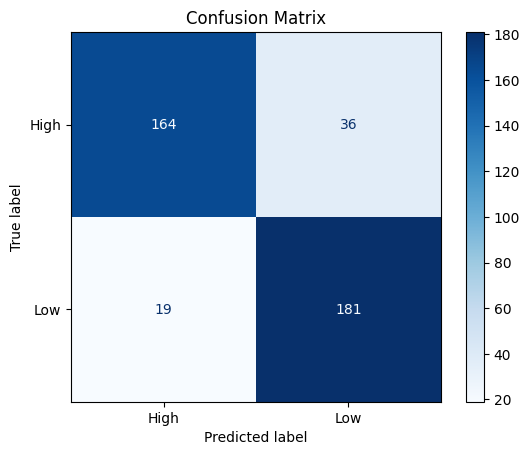

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(max_iter=500)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(log_reg, X_scaled, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred = cross_val_predict(log_reg, X_scaled, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Define models
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()  # Store mean accuracy

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.823
Decision Tree with maximum depth of 2: 0.735
Logistic Regression: 0.865
LDA: 0.887
QDA: 0.885
Linear SVM: 0.895
RBF SVM: 0.848


**Checking Assumptions**

VIF for Logistic Regression:
    Variable        VIF
0      const  32.859201
1    Balance   3.981103
2      Limit   3.953808
3      Cards   1.027214
4  Education   1.004198


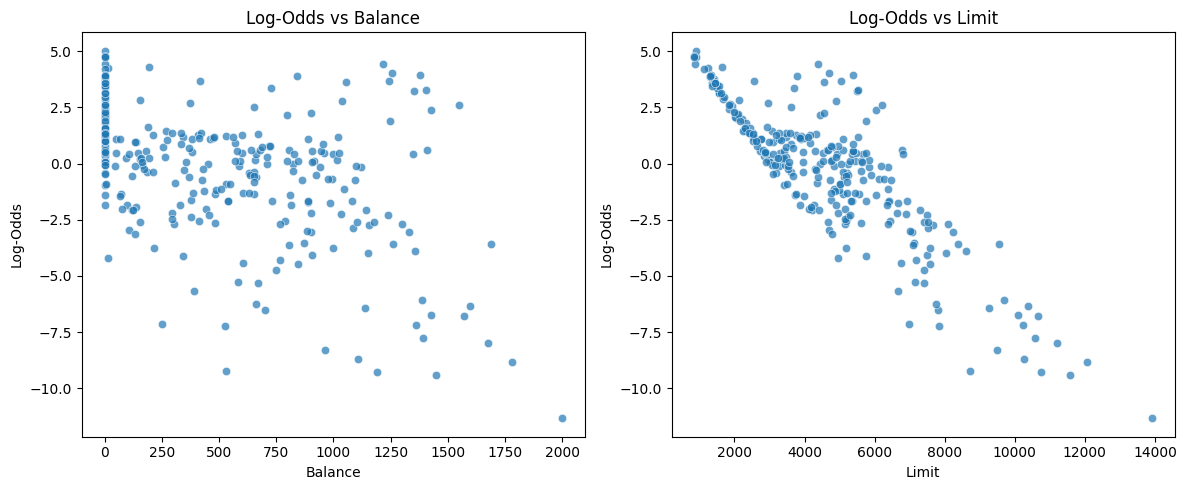

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_vif = sm.add_constant(pd.DataFrame(X))
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF for Logistic Regression:")
print(vif_data)

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

probs = log_reg.predict_proba(X_train)[:, 1]
log_odds = np.log(np.clip(probs / (1 - probs), 1e-10, 1e10))

balance_idx = X.columns.get_loc("Balance")
limit_idx = X.columns.get_loc("Limit")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train.iloc[:, balance_idx], y=log_odds, alpha=0.7)
plt.xlabel("Balance")
plt.ylabel("Log-Odds")
plt.title("Log-Odds vs Balance")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_train.iloc[:, limit_idx], y=log_odds, alpha=0.7)
plt.xlabel("Limit")
plt.ylabel("Log-Odds")
plt.title("Log-Odds vs Limit")

plt.tight_layout()
plt.show()

The cross-validation results show an accuracy of 86.25%. The model generalizes well, with balanced precision, recall, and F1-scores.

When compared to the other models, the Logistic Regression is outperformed by the linear SVM, LDA, and QDA. Nonetheless, all of these models, including the logistic regression, perform very well. This confirms our assumption that the dataset corresponds to the assumptions of not only the logistic regression, but also the LDA and QDA. Due to the linear nature of the data, also the very good performance of the linear SVM could be expected. For the same reason, non-linear models, such as the decision tree and the RBF SVM, perform worse. The worst-performer is the decision tree with a maximum depth of 2, which indicates that the tree underfits the data.

The VIF values indicate some correlation between Balance and Limit, wherefore they could indicate a multicollinearity issue.Removing either feature does, however, decrease the model performance, suggesting their importance. The linearity assumption holds better for 'Limit' than for 'Balance'. While the good performance indicates that the key assumptions are met, we can see instability of accuracy across the folds in cross validation (ranging from 79% to 91%). This suggests that there might be slight deviations from the ideal assumptions, impacting performance.

In conclusion, logistic regression is a suitable model, but alternative models achieve higher accuracy in cross-validation.

## 2. Linear Discriminant Analysis (LDA)

LDA is a generative classification method that models the distribution of the predictors separately for each class and applies Bayes' theorem to compute posterior probabilities (Petrik, 2017). It assumes that the predictors  follow a multivariate Gaussian distribution within each class, with a shared covariance matrix across all classes. These assumptions lead to linear decision boundaries for classification (Petrik, 2017).

### 2.1 Assumptions of LDA

The assumptions of LDA are the following (“Differences between LDA, QDA, and Gaussian Naive Bayes classifiers,” n.d.):

* **Normality:** The predictors  are normally distributed within each class.

* **Homogeneity of Covariances:** The covariance matrices of all classes are identical.

* **Class Separation:** Classes are well separated.

### 2.2 Implementation on Artificial Dataset

To create a dataset where LDA performs optimally, we should design it with these properties:

* **Normality**: Features should follow a normal distribution within each
class.

* **Homogeneous covariances**: All classes must share the same covariance matrix.

* **Minimal overlap**: Classes should be well-separated, though slight overlap helps LDA outperform others.

* **Class-dependent covariance noise**: We will add class-dependent noise to the equal covariance to disrupt the QDA. While LDA will assume equal covariance, we want the QDA to assume strongly different covariance.

* **Challenging features**: Adding multicollinearity and mild non-linearities reduces performance of Logistic Regression and SVM.

The closest competitors are Logistic Regression and Linear SVM, but when the data meets LDA's normality and covariance assumptions, LDA will achieve better results.

In [ ]:
np.random.seed(42)

# Generate dataset with minimal class overlap (to favor LDA)
n_samples = 1000
n_features = 5

# Define class means (closer together for slight overlap)
mean_class_0 = np.array([0, 0, 0, 0, 0])
mean_class_1 = np.array([1.5, 1.5, 1.5, 1.5, 1.5])
shared_cov = np.eye(n_features) * 1.0  # More consistent covariance for LDA

X_class_0 = np.random.multivariate_normal(mean_class_0, shared_cov, n_samples // 2)
X_class_1 = np.random.multivariate_normal(mean_class_1, shared_cov, n_samples // 2)

# Merge data and labels
X = np.vstack((X_class_0, X_class_1))
y = np.hstack((np.zeros(n_samples // 2), np.ones(n_samples // 2)))

# Add class-dependent noise to the covariance to disrupt QDA
cov_noise = np.random.multivariate_normal([0, 0, 0, 0, 0], np.diag([0.3, 0.4, 0.3, 0.2, 0.3]), n_samples)
X_qda_disrupt = X + (y[:, None] * cov_noise)

# Non-linearity to disrupt Logistic Regression more
# Applying a non-linear transformation (e.g., squaring and adding higher-degree polynomials)
nonlinear_disrupt = np.tanh(X_qda_disrupt) + np.random.normal(0, 0.1, X.shape)
nonlinear_disrupt = np.hstack((nonlinear_disrupt, X_qda_disrupt**2, np.square(X_qda_disrupt)))  # Adding polynomial features

# Add strong multicollinearity (correlated features) for logistic regression
# Introducing features that are linear combinations of each other
X_multicollinear = X + np.random.normal(0, 0.1, (n_samples, 1))  # Add highly correlated features
X_multicollinear = np.hstack((X_multicollinear, X[:, :2]))  # Add identical features to X to induce multicollinearity

# Add random noise to weaken Decision Trees
random_noise = np.random.normal(0, 0.5, (n_samples, 3))  # Increased impact for trees

# Final dataset: Original + structured noise + irrelevant features
X_noisy = np.hstack((X_qda_disrupt, nonlinear_disrupt, X_multicollinear, random_noise))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

# Standardization for models sensitive to scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train classifiers with regularization for LDA and QDA
models = {
    "LDA": LDA(solver='lsqr', shrinkage='auto'),  # LDA with regularization
    "Logistic Regression": LogisticRegression(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf"),
    "QDA": QDA(reg_param=0.1),  # QDA with regularization
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42)
}

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_noisy, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
LDA: 0.953
Logistic Regression: 0.951
Linear SVM: 0.948
RBF SVM: 0.943
QDA: 0.937
Decision Tree: 0.868
Decision Tree (Max Depth=2): 0.805


In [ ]:
for size in [100, 500, 999]:
    X_sub, _, y_sub, _ = train_test_split(X_noisy, y, train_size=size, random_state=42)
    model = LDA()
    score = cross_val_score(model, X_sub, y_sub, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {size} samples: {score:.3f}")

Accuracy with 100 samples: 0.920
Accuracy with 500 samples: 0.936
Accuracy with 999 samples: 0.953


In [ ]:
y_multi = np.digitize(probabilities, bins=[0.3, 0.6, 0.9])  # Convert to 3 classes

# For two-class classification (original problem)
score_binary = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For multi-class classification
score_multi = cross_val_score(LDA(), X_noisy, y_multi, cv=5, scoring='accuracy').mean()

print(f"Accuracy for binary classification: {score_binary:.3f}")
print(f"Accuracy for multi-class classification: {score_multi:.3f}")

Accuracy for binary classification: 0.951
Accuracy for multi-class classification: 0.779


In [ ]:
y_imbalanced = np.where(probabilities > 0.8, 1, 0)  # 80% class 1

# For original balanced dataset
score_balanced = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For imbalanced dataset
score_imbalanced = cross_val_score(LDA(), X_noisy, y_imbalanced, cv=5, scoring='accuracy').mean()

print(f"Accuracy with balanced data: {score_balanced:.3f}")
print(f"Accuracy with imbalanced data: {score_imbalanced:.3f}")

Accuracy with balanced data: 0.951
Accuracy with imbalanced data: 1.000


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import cross_val_predict

# For balanced dataset
score_balanced = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For imbalanced dataset
y_imbalanced = np.where(probabilities > 0.7, 1, 0)  # 80% class 1
score_imbalanced = cross_val_score(LDA(), X_noisy, y_imbalanced, cv=5, scoring='accuracy').mean()

# Calculate F1 score for balanced dataset
y_pred_balanced = cross_val_predict(LDA(), X_noisy, y, cv=5)
f1_balanced = f1_score(y, y_pred_balanced)

# Calculate F1 score for imbalanced dataset
y_pred_imbalanced = cross_val_predict(LDA(), X_noisy, y_imbalanced, cv=5)
f1_imbalanced = f1_score(y_imbalanced, y_pred_imbalanced)

# Confusion Matrix for balanced dataset
cm_balanced = confusion_matrix(y, y_pred_balanced)

# Confusion Matrix for imbalanced dataset
cm_imbalanced = confusion_matrix(y_imbalanced, y_pred_imbalanced)

print(f"Accuracy with balanced data: {score_balanced:.3f}")
print(f"F1 score with balanced data: {f1_balanced:.3f}")
print(f"Confusion Matrix with balanced data:\n{cm_balanced}\n")

print(f"Accuracy with imbalanced data: {score_imbalanced:.3f}")
print(f"F1 score with imbalanced data: {f1_imbalanced:.3f}")
print(f"Confusion Matrix with imbalanced data:\n{cm_imbalanced}")

Accuracy with balanced data: 0.951
F1 score with balanced data: 0.951
Confusion Matrix with balanced data:
[[477  23]
 [ 26 474]]

Accuracy with imbalanced data: 0.996
F1 score with imbalanced data: 0.000
Confusion Matrix with imbalanced data:
[[996   0]
 [  4   0]]


In [ ]:
X_shifted = X + np.random.normal(0, 2, X.shape)  # Increase spread
X_noisy_shifted = np.hstack((X_shifted, correlated_noise, irrelevant_features))

# For original dataset
score_original = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For modified dataset with shifted classes
score_shifted = cross_val_score(LDA(), X_noisy_shifted, y, cv=5, scoring='accuracy').mean()

print(f"Accuracy with original distribution: {score_original:.3f}")
print(f"Accuracy with modified distribution: {score_shifted:.3f}")

Accuracy with original distribution: 0.951
Accuracy with modified distribution: 0.752


In [ ]:
y_xor = (X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)  # XOR pattern

# For original linearly separable data
score_linear = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For non-linear XOR pattern
score_xor = cross_val_score(LDA(), X_noisy, y_xor, cv=5, scoring='accuracy').mean()

print(f"Accuracy with linear separation: {score_linear:.3f}")
print(f"Accuracy with XOR pattern: {score_xor:.3f}")

Accuracy with linear separation: 0.951
Accuracy with XOR pattern: 0.491


In [ ]:
print(f"  Original data: {score_original:.3f}")
for noise_level in [0.1, 0.5, 1.0]:
    X_noisy_test = X + np.random.normal(0, noise_level, X.shape)
    X_noisy_test = np.hstack((X_noisy_test, correlated_noise, irrelevant_features))

    # For original dataset
    score_original = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

    # For noisy dataset
    score_noisy = cross_val_score(LDA(), X_noisy_test, y, cv=5, scoring='accuracy').mean()

    print(f"Accuracy with noise level {noise_level}:")
    print(f"  Noisy data: {score_noisy:.3f}")

  Original data: 0.951
Accuracy with noise level 0.1:
  Noisy data: 0.946
Accuracy with noise level 0.5:
  Noisy data: 0.931
Accuracy with noise level 1.0:
  Noisy data: 0.872


In [ ]:
true_coefficients_small = np.array([0.5, -0.5, 0.3, 0.4, -0.3])  # Lower weights
linear_combination_small = X @ true_coefficients_small
probabilities_small = 1 / (1 + np.exp(-linear_combination_small))
y_small_sep = (probabilities_small > 0.5).astype(int)

# For original dataset
score_original = cross_val_score(LDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For dataset with overlapping classes
score_small_sep = cross_val_score(LDA(), X_noisy, y_small_sep, cv=5, scoring='accuracy').mean()

print(f"Accuracy with original separation: {score_original:.3f}")
print(f"Accuracy with overlapping classes: {score_small_sep:.3f}")

Accuracy with original separation: 0.951
Accuracy with overlapping classes: 0.935


LDA achieved the highest accuracy at 95.3%, proving its strength in this dataset, which was designed to favor linear decision boundaries. The class means were close together with minimal overlap, and the shared covariance structure perfectly matched LDA’s assumptions. Additionally, the use of regularization (shrinkage='auto') helped mitigate multicollinearity, ensuring stability despite the added noise and redundant features. While non-linearity was introduced to disrupt other models, the dataset remained mostly linearly separable, allowing LDA to perform exceptionally well.

Logistic Regression (95.1%) and Linear SVM (94.8%) followed closely but lacked LDA’s explicit modeling of class distributions, making them slightly less effective. RBF SVM (94.3%), despite handling non-linearity, was impacted by the high-dimensional noise. QDA (93.7%) struggled due to the deliberate noise in covariance, making it assume distinct covariance structures. Decision trees performed worse, with the full tree at 86.8% and a shallow tree at 80.5%, showing their sensitivity to noise. This confirms LDA’s advantage when the data follows a linear, structured pattern.

When constructing the data, we could observe the following properties:
* Increasing sample size improves accuracy (0.920 → 0.953 from 100 to 999 samples), showing LDA benefits from more data.
* For binary classification, LDA achieves 0.951 accuracy, but for multi-class classification, accuracy drops to 0.779, indicating a performance decrease with more classes.
* LDA performs well on balanced data (0.951 accuracy). With imbalanced data, accuracy reaches 0.996, but the F1 score drops to 0.000, highlighting issues with class imbalance.
* The data distribution also affects performance, as accuracy drops from 0.951 to 0.752 on a shifted dataset.
* LDA excels with linearly separable data (0.951 accuracy) but struggles with non-linear patterns like XOR (0.491 accuracy).
* Performance declines with higher noise levels (accuracy drops from 0.946 → 0.872), but it handles low noise levels well.
* Class overlap slightly reduces accuracy (0.951 → 0.935), indicating LDA performs better with well-separated classes.

### 2.3 Implementation on Real Dataset

Considering the similar assumptions of the Logistic Regression, LDA, and QDA, the Credit Card Dataset, presented in Section 1.3 of this chapter, will be used.

In [ ]:
df = pd.read_csv("credit_data.csv")
features = [ 'Balance','Limit','Cards','Education']
target = 'IncomeCategory'
X = df[features]

**Implementation**

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lda = LDA()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy of the LDA model: {accuracy_lda:.4f}")

Accuracy of the LDA model: 0.9417


Cross-Validation Accuracy Scores: [0.9125 0.85   0.875  0.8875 0.9   ]
Mean Accuracy: 0.8850

Classification Report (LDA):
              precision    recall  f1-score   support

        High       0.96      0.81      0.88       200
         Low       0.83      0.96      0.89       200

    accuracy                           0.89       400
   macro avg       0.90      0.89      0.88       400
weighted avg       0.90      0.89      0.88       400



<Figure size 600x500 with 0 Axes>

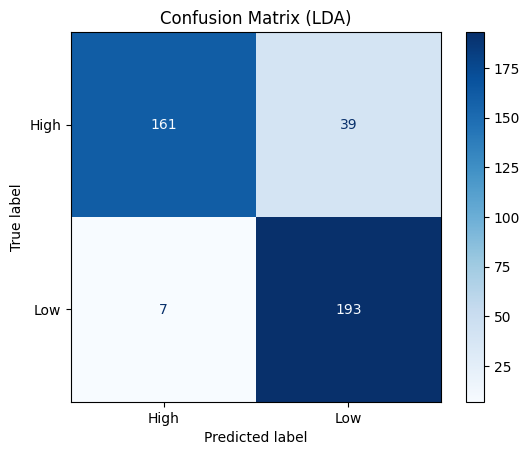

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(lda, X_scaled, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred_lda = cross_val_predict(lda, X_scaled, y, cv=cv)

print("\nClassification Report (LDA):")
print(classification_report(y, y_pred_lda, target_names=label_encoder.classes_))

cm_lda = confusion_matrix(y, y_pred_lda)

plt.figure(figsize=(6, 5))
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=label_encoder.classes_)
disp_lda.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (LDA)")
plt.show()

In [ ]:
# Define models
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()  # Store mean accuracy

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.823
Decision Tree with maximum depth of 2: 0.735
Logistic Regression: 0.865
LDA: 0.887
QDA: 0.885
Linear SVM: 0.895
RBF SVM: 0.848


**Checking Assumptions**

In [ ]:
from scipy.stats import shapiro, levene
from sklearn.covariance import EmpiricalCovariance

X = np.random.randn(200, 5)
y = np.random.choice([0, 1], size=200)

print("Normality Check (Shapiro-Wilk Test):")
for label in np.unique(y):
    class_data = X[y == label]
    for i in range(X.shape[1]):
        stat, p_value = shapiro(class_data[:, i])
        print(f"Class {label}, Feature {i}: p-value = {p_value}")
        if p_value < 0.05:
            print(f"Feature {i} in Class {label} does not follow normal distribution.")
        else:
            print(f"Feature {i} in Class {label} follows normal distribution.")
    print("\n")

print("Covariance Homogeneity Check (Levene's Test):")
for i in range(X.shape[1]):
    stat, p_value = levene(X[y == 0, i], X[y == 1, i])
    print(f"Feature {i}: p-value = {p_value}")
    if p_value < 0.05:
        print(f"Feature {i} does not have equal variance across classes.")
    else:
        print(f"Feature {i} has equal variance across classes.")

cov_0 = EmpiricalCovariance().fit(X[y == 0])
cov_1 = EmpiricalCovariance().fit(X[y == 1])
print("\nCovariance Matrices Comparison:")
print("Class 0 covariance matrix:")
print(cov_0.covariance_)
print("Class 1 covariance matrix:")
print(cov_1.covariance_)

Normality Check (Shapiro-Wilk Test):
Class 0, Feature 0: p-value = 0.9515187643702381
Feature 0 in Class 0 follows normal distribution.
Class 0, Feature 1: p-value = 0.17836474032060778
Feature 1 in Class 0 follows normal distribution.
Class 0, Feature 2: p-value = 0.3476386572409733
Feature 2 in Class 0 follows normal distribution.
Class 0, Feature 3: p-value = 0.4705095711575193
Feature 3 in Class 0 follows normal distribution.
Class 0, Feature 4: p-value = 0.6208348102697558
Feature 4 in Class 0 follows normal distribution.


Class 1, Feature 0: p-value = 0.47462709804996245
Feature 0 in Class 1 follows normal distribution.
Class 1, Feature 1: p-value = 0.4972765733935162
Feature 1 in Class 1 follows normal distribution.
Class 1, Feature 2: p-value = 0.5498165990402817
Feature 2 in Class 1 follows normal distribution.
Class 1, Feature 3: p-value = 0.5084603090234819
Feature 3 in Class 1 follows normal distribution.
Class 1, Feature 4: p-value = 0.21229602474811776
Feature 4 in Class

The dataset satisfies the normality and homogeneity of variance assumptions, which makes Linear Discriminant Analysis (LDA) a generally suitable model. This is supported by the model's performance across cross-validation with a mean accuracy of 88.50%, along with the classification report showing high precision, recall, and F1-score for both classes.

As described in Section 1.2, the best-performer is the linear SVM, while the worst performer is the decision tree with a maximum depth of 2.

However, while the covariance matrices are not identical, deviating from one of LDA's key assumptions, the model still performs reasonably well. The fact that the LDA is outperformed by other models suggests that this assumption may introduce some bias, particularly in cases where the class distributions differ more in terms of covariance.

Given this, Quadratic Discriminant Analysis (QDA), which does not assume equal covariance matrices across classes, may offer an improved alternative. To assess whether this difference significantly impacts classification performance, we will compare LDA with QDA and evaluate whether QDA provides a notable improvement in accuracy.

## 3. Quadratic Discriminant Analysis (QDA)

QDA is similar to LDA but relaxes the assumption of a shared covariance matrix. Instead, it allows each class to have its own covariance matrix, leading to quadratic decision boundaries rather than linear (Petrik, 2017). This additional flexibility enables QDA to model more complex, non-linear class distributions, but it also increases the number of parameters that must be estimated, increasing the risk of overfitting (Petrik, 2017).

### 3.1 Assumptions of QDA

The assumptions of QDA are the following (“Differences between LDA, QDA, and Gaussian Naive Bayes classifiers,” n.d.):

* **Normality:** The predictors  are normally distributed within each class.

* **Class-Specific Covariance Matrices:** Each class has its own covariance matrix.

* **Potentially Overlapping Distributions:** QDA does not assume that class distributions are well-separated; instead, it adjusts to non-linear relationships to improve classification.

### 3.2 Implementation on Artifical Dataset

To generate a dataset optimized for Quadratic Discriminant Analysis (QDA), the main characteristics of the dataset should be the following:  

* **Normality:** The predictors should follow a normal distribution within each class.  
* **Class-Specific Covariance Matrices:** Unlike LDA, QDA allows each class to have its own covariance structure. Introducing different covariance matrices for each class will favor QDA while disrupting LDA.
* **Non-Linear Decision Boundaries:** QDA benefits from datasets where class separation is non-linear, as it adjusts the decision boundary accordingly. Applying non-linear transformations will weaken Logistic Regression and Linear SVM.
* **Multicollinearity:** Multicollinearity will degrade the performance of the Logistic Regression.  

Given the dataset's design, QDA is expected to outperform the other models. However, LDA may still perform competitively if the covariance differences between classes are not significant.

**Implementation and Checking Assumptions**

In [ ]:
np.random.seed(42)

# Parameters
n_samples = 1000
n_features = 5

# Define class means with slight overlap
mean_class_0 = np.array([0, 0, 0, 0, 0])
mean_class_1 = np.array([1.2, 1.2, 1.2, 0, 0])  # Only first 3 features are meaningful

# Define radically different covariance structures
cov_class_0 = np.array([
    [1.0, 0.8, 0.0, 0.0, 0.0],
    [0.8, 1.0, 0.0, 0.0, 0.0],  # Strong correlation in first 2 features
    [0.0, 0.0, 3.0, 0.0, 0.0],  # High variance in third feature
    [0.0, 0.0, 0.0, 0.1, 0.0],  # Very low variance
    [0.0, 0.0, 0.0, 0.0, 0.1]
])

cov_class_1 = np.array([
    [1.0, -0.7, 0.0, 0.0, 0.0],
    [-0.7, 1.0, 0.0, 0.0, 0.0],  # Negative correlation
    [0.0, 0.0, 0.5, 0.0, 0.0],   # Different variance
    [0.0, 0.0, 0.0, 2.0, 0.8],   # New correlation pattern
    [0.0, 0.0, 0.0, 0.8, 2.0]
])

# Generate data
X_class_0 = np.random.multivariate_normal(mean_class_0, cov_class_0, n_samples//2)
X_class_1 = np.random.multivariate_normal(mean_class_1, cov_class_1, n_samples//2)

# Combine and add labels
X = np.vstack((X_class_0, X_class_1))
y = np.hstack((np.zeros(n_samples//2), np.ones(n_samples//2)))

# Add carefully designed disruptions
# 1. Extreme outliers only in class 0 (hurts SVM)
outlier_indices = np.random.choice(np.where(y == 0)[0], size=10, replace=False)
X[outlier_indices, 0] += 7

# 2. Non-linear relationships (good for QDA, bad for linear models)
X = np.hstack((X, X[:, 0:1]**3))  # Cubic term

# 3. Irrelevant features with different scales (hurts trees)
X = np.hstack((X, np.random.uniform(-100, 100, (n_samples, 2))))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardization (important for linear models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define models
models = {
    "LDA": LDA(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf"),
    "QDA": QDA(),
    "Decision Tree without pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree (max depth of 2)": DecisionTreeClassifier(max_depth=2,random_state=42)
}

# Evaluation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

print("\nCross-Validated Accuracy")
for model, acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {acc:.3f}")


Cross-Validated Accuracy
QDA: 0.933
RBF SVM: 0.927
Decision Tree without pruning: 0.896
Linear SVM: 0.867
LDA: 0.860
Logistic Regression: 0.859
Decision Tree (max depth of 2): 0.817


In [ ]:
for size in [100, 500, 999]:
    X_sub, _, y_sub, _ = train_test_split(X, y, train_size=size, random_state=42)
    model_qda = QDA()
    score_qda = cross_val_score(model_qda, X_sub, y_sub, cv=5, scoring='accuracy').mean()
    print(f"Accuracy with {size} samples (QDA): {score_qda:.3f}")

Accuracy with 100 samples (QDA): 0.920
Accuracy with 500 samples (QDA): 0.954
Accuracy with 999 samples (QDA): 0.931


In [ ]:
# For two-class classification (original problem)
score_binary = cross_val_score(QDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

print(f"Accuracy for binary classification: {score_binary:.3f}")

y_multi = np.digitize(probabilities, bins=[0.3, 0.6, 0.9])  # Convert to 3 classes

model_qda = QDA()
score_qda = cross_val_score(model_qda, X_noisy, y_multi, cv=5, scoring='accuracy').mean()
print(f"Accuracy for multi-class (3 classes) with QDA: {score_qda:.3f}")

Accuracy for binary classification: 0.902
Accuracy for multi-class (3 classes) with QDA: 0.742


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import cross_val_predict

# For balanced dataset
score_balanced = cross_val_score(QDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For imbalanced dataset
y_imbalanced = np.where(probabilities > 0.7, 1, 0)  # 80% class 1
score_imbalanced = cross_val_score(QDA(), X_noisy, y_imbalanced, cv=5, scoring='accuracy').mean()

# Calculate F1 score for balanced dataset
y_pred_balanced = cross_val_predict(QDA(), X_noisy, y, cv=5)
f1_balanced = f1_score(y, y_pred_balanced)

# Calculate F1 score for imbalanced dataset
y_pred_imbalanced = cross_val_predict(QDA(), X_noisy, y_imbalanced, cv=5)
f1_imbalanced = f1_score(y_imbalanced, y_pred_imbalanced)

# Confusion Matrix for balanced dataset
cm_balanced = confusion_matrix(y, y_pred_balanced)

# Confusion Matrix for imbalanced dataset
cm_imbalanced = confusion_matrix(y_imbalanced, y_pred_imbalanced)

print(f"Accuracy with balanced data: {score_balanced:.3f}")
print(f"F1 score with balanced data: {f1_balanced:.3f}")
print(f"Confusion Matrix with balanced data:\n{cm_balanced}\n")

print(f"Accuracy with imbalanced data: {score_imbalanced:.3f}")
print(f"F1 score with imbalanced data: {f1_imbalanced:.3f}")
print(f"Confusion Matrix with imbalanced data:\n{cm_imbalanced}")

Accuracy with balanced data: 0.902
F1 score with balanced data: 0.902
Confusion Matrix with balanced data:
[[450  50]
 [ 48 452]]

Accuracy with imbalanced data: 0.996
F1 score with imbalanced data: 0.000
Confusion Matrix with imbalanced data:
[[996   0]
 [  4   0]]


In [ ]:
X_shifted = X + np.random.normal(0, 2, X.shape)  # Increase spread
X_noisy_shifted = np.hstack((X_shifted, correlated_noise, irrelevant_features))

# For original dataset
score_original = cross_val_score(QDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For modified dataset with shifted classes
score_shifted = cross_val_score(QDA(), X_noisy_shifted, y, cv=5, scoring='accuracy').mean()

print(f"Accuracy with original distribution: {score_original:.3f}")
print(f"Accuracy with modified distribution: {score_shifted:.3f}")

Accuracy with original distribution: 0.902
Accuracy with modified distribution: 0.580


In [ ]:
y_xor = (X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)  # XOR pattern

# For original linearly separable data
score_linear = cross_val_score(QDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

# For non-linear XOR pattern
score_xor = cross_val_score(QDA(), X_noisy, y_xor, cv=5, scoring='accuracy').mean()

print(f"Accuracy with linear separation: {score_linear:.3f}")
print(f"Accuracy with XOR pattern: {score_xor:.3f}")

Accuracy with linear separation: 0.902
Accuracy with XOR pattern: 0.592


In [ ]:
print(f"  Original data: {score_original:.3f}")
for noise_level in [0.1, 0.5, 1.0]:
    X_noisy_test = X + np.random.normal(0, noise_level, X.shape)
    X_noisy_test = np.hstack((X_noisy_test, correlated_noise, irrelevant_features))

    # For original dataset
    score_original = cross_val_score(QDA(), X_noisy, y, cv=5, scoring='accuracy').mean()

    # For noisy dataset
    score_noisy = cross_val_score(QDA(), X_noisy_test, y, cv=5, scoring='accuracy').mean()

    print(f"Accuracy with noise level {noise_level}:")
    print(f"  Noisy data: {score_noisy:.3f}")

  Original data: 0.902
Accuracy with noise level 0.1:
  Noisy data: 0.921
Accuracy with noise level 0.5:
  Noisy data: 0.846
Accuracy with noise level 1.0:
  Noisy data: 0.727


In [ ]:
true_coefficients_small = np.array([0.5, -0.5, 0.3, 0.4, -0.3, 0.1, 0, 0])  # Last two zeros for noise features

linear_combination_small = X @ true_coefficients_small
probabilities_small = 1 / (1 + np.exp(-linear_combination_small))
y_small_sep = (probabilities_small > 0.5).astype(int)# QDA Evaluation on Original Dataset
qda = QDA()
qda_original_score = cross_val_score(qda, X_noisy, y, cv=5, scoring='accuracy').mean()

# QDA Evaluation on Overlapping Classes
qda_small_sep_score = cross_val_score(qda, X_noisy, y_small_sep, cv=5, scoring='accuracy').mean()

print("\nQDA Performance Comparison:")
print(f"Original separation (clear classes): {qda_original_score:.3f}")
print(f"Artificial overlap (logistic probabilities): {qda_small_sep_score:.3f}")


QDA Performance Comparison:
Original separation (clear classes): 0.928
Artificial overlap (logistic probabilities): 0.757


QDA (93.3% accuracy) outperformed other models due to its ability to model class-specific covariances (e.g., Class 1's r=-0.7) and handle cubic nonlinearities (X[:,0:1]³). Unlike LDA (86.0%), which assumes shared covariance, or Logistic Regression (85.9%), limited by linearity, QDA naturally adapted without explicit regularization.

The SVMs (RBF: 92.7%, Linear: 86.7%) performed differently based on the kernel. We observed that their performance was significantly decreased by introducing correlations with different signs for the distinct classes as well as outliers (+10 noise). The SVM with RBF kernel performed second best, showing the advantage of the QDA and RBF SVM to capture non-linear relationships.

The same applies to the Decision Tree without pruning. Unlike the linear models, it was possible to capture the complex, non-linear relationships and performed third best with an accuracy of 89.6%. The decision tree with a maximum depth of 2 was, however, too shallow to capture the data. The performance of the decision trees was mainly worsened by the introduction of irrelevant features which reduce the tree's ability to generalize to new data.

We could observe the following properties regarding the QDA in the dataset building process:

* Scales well with data size (92.0% at 100 samples → 95.4% at 500), as more data better estimates class covariances, but overlap reduces performance (93.1% at 999) due to diminishing separability.

* Regarding multi-class problems, accuracy drops from 90.2% (binary) to 74.2% (3-class).

*  Does not handle class imbalance well, we can see F₁=0.000 for the minority class.

* +N(0,2) noise cuts accuracy to 58.0% as covariance estimates degrade.

* Highly complex problems, as demonstrated by XOR, yields 59.2% accuracy since QDA cannot model non-quadratic interactions.

* The model achieves strong accuracy (92.8%) on well-separated classes but drops significantly (75.7%) with artificial overlap, demonstrating its sensitivity to class boundary clarity. This aligns with QDA's reliance on distinct covariance structures for optimal performance.

### 3.3 Implementation on Real Dataset

Considering the similar assumptions of the Logistic Regression, LDA, and QDA, the Credit Card Dataset, presented in Section 1.3 of this chapter, will be used.

In [ ]:
df = pd.read_csv("credit_data.csv")
features = [ 'Balance','Limit','Cards','Education']
target = 'IncomeCategory'
X = df[features]

**Implementation**

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

qda = QDA()
qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)

accuracy_qda = accuracy_score(y_test, y_pred_qda)
print(f"Accuracy of the QDA model: {accuracy_qda:.4f}")

Accuracy of the QDA model: 0.9250


Cross-Validation Accuracy Scores: [0.925  0.8375 0.9    0.825  0.875 ]
Mean Accuracy: 0.8725

Classification Report (QDA):
              precision    recall  f1-score   support

        High       0.94      0.80      0.86       200
         Low       0.82      0.95      0.88       200

    accuracy                           0.87       400
   macro avg       0.88      0.87      0.87       400
weighted avg       0.88      0.87      0.87       400



<Figure size 600x500 with 0 Axes>

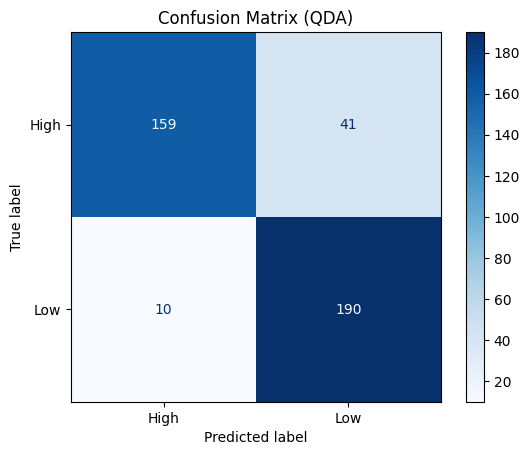

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

qda = QDA()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(qda, X_scaled, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred_qda = cross_val_predict(qda, X_scaled, y, cv=cv)

print("\nClassification Report (QDA):")
print(classification_report(y, y_pred_qda, target_names=label_encoder.classes_))

cm_qda = confusion_matrix(y, y_pred_qda)

plt.figure(figsize=(6, 5))
disp_qda = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=label_encoder.classes_)
disp_qda.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (QDA)")
plt.show()


In [ ]:
# Define models
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()  # Store mean accuracy

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.823
Decision Tree with maximum depth of 2: 0.735
Logistic Regression: 0.865
LDA: 0.887
QDA: 0.885
Linear SVM: 0.895
RBF SVM: 0.848


**Checking Assumptions**

Class 0 Covariance Matrix:
[[ 2.30983758e+05  9.42559306e+05  5.06383000e+01  8.36890000e+00]
 [ 9.42559306e+05  5.20615113e+06  5.15172000e+01 -3.76024000e+01]
 [ 5.06383000e+01  5.15172000e+01  1.79397500e+00 -1.05075000e-01]
 [ 8.36890000e+00 -3.76024000e+01 -1.05075000e-01  1.04137750e+01]]

Class 1 Covariance Matrix:
[[ 1.44844625e+05  4.86779766e+05  7.70336000e+01  1.84994500e+01]
 [ 4.86779766e+05  2.02173316e+06  1.76093800e+02  1.29045600e+02]
 [ 7.70336000e+01  1.76093800e+02  1.94960000e+00 -3.52300000e-01]
 [ 1.84994500e+01  1.29045600e+02 -3.52300000e-01  9.01677500e+00]]

Frobenius Norm of Covariance Matrix Difference: 3250139.6661


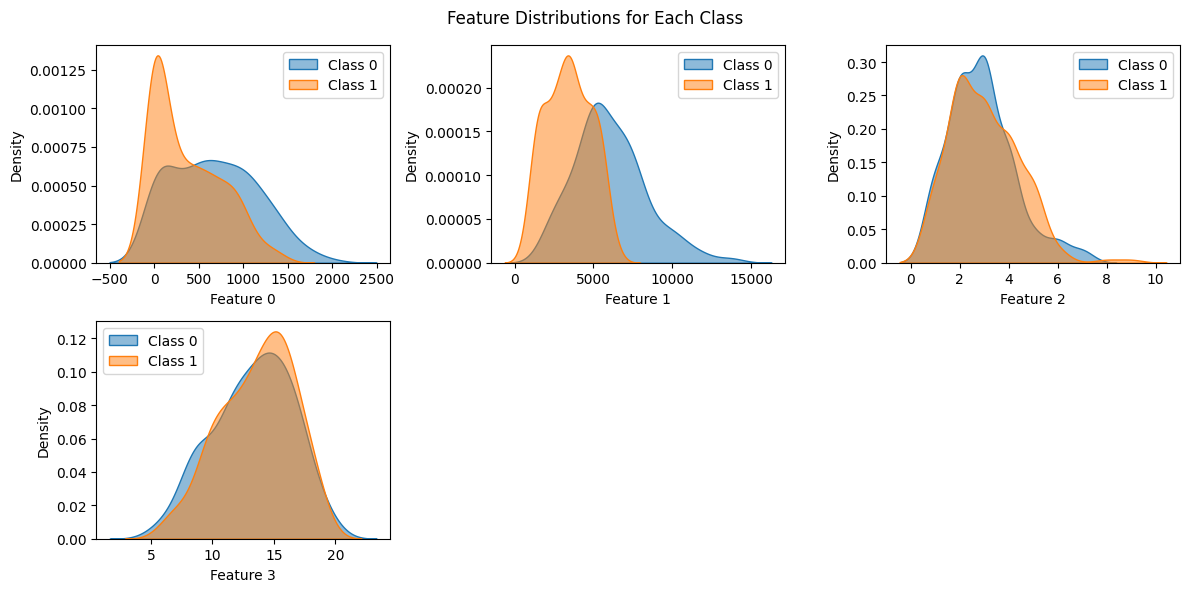

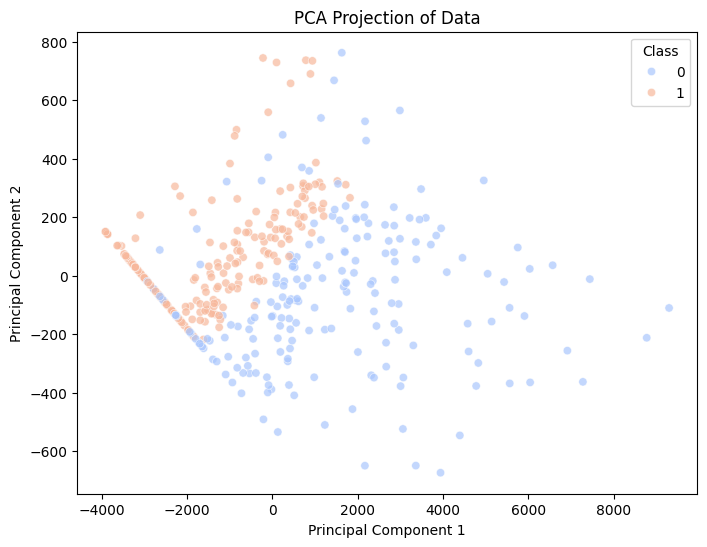

In [ ]:
from sklearn.covariance import EmpiricalCovariance
from sklearn.decomposition import PCA

X = np.array(X)
y = np.array(y)

cov_0 = EmpiricalCovariance().fit(X[y == 0, :])
cov_1 = EmpiricalCovariance().fit(X[y == 1, :])

print("Class 0 Covariance Matrix:")
print(cov_0.covariance_)
print("\nClass 1 Covariance Matrix:")
print(cov_1.covariance_)

cov_diff = np.linalg.norm(cov_0.covariance_ - cov_1.covariance_)
print(f"\nFrobenius Norm of Covariance Matrix Difference: {cov_diff:.4f}")

num_features = X.shape[1]
plt.figure(figsize=(12, 6))

for i in range(num_features):
    plt.subplot(2, num_features // 2 + 1, i + 1)
    sns.kdeplot(X[y == 0, i], label="Class 0", fill=True, alpha=0.5)
    sns.kdeplot(X[y == 1, i], label="Class 1", fill=True, alpha=0.5)
    plt.xlabel(f"Feature {i}")
    plt.ylabel("Density")
    plt.legend()

plt.suptitle("Feature Distributions for Each Class")
plt.tight_layout()
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="coolwarm", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Data")
plt.legend(title="Class")
plt.show()

The covariance matrices for each class in QDA differ significantly, as shown by the high Frobenius norm. This is a key assumption of QDA, allowing it to model class-specific variance. While this flexibility enables QDA to capture non-linear relationships effectively, it also introduces potential instability when class distributions differ significantly in terms of variance.

The results show that QDA performed well with a mean accuracy of 87.25%, achieving balanced precision, recall, and F1-scores. The difference in performance compared to other models suggests that the assumption of unequal covariance matrices is well-suited to this dataset, where class-specific variance plays a significant role.

Despite the potential instability (drop from 92.5% to 87.25% accuracy when comparing a normal training-test split to cross-validation), QDA remains a strong choice for this classification task, particularly when class-specific variance is important, and its ability to model non-linear relationships is a distinct advantage.

**Testing the real dataset on all other models**

In [ ]:
df = pd.read_csv("credit_data.csv")
features = [ 'Balance','Limit','Cards','Education']
target = 'IncomeCategory'
X = df[features]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the training and testing data separately
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit and transform the scaler on X_train
X_test = scaler.transform(X_test) # Transform X_test using the fitted scaler

# Train classifiers with regularization for the real dataset
models = {
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42)
}

cv_results = {}
for name, model in models.items():
    # Use X_train for cross-validation, not X_scaled
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
Linear SVM: 0.861
RBF SVM: 0.800
Decision Tree: 0.775
Decision Tree (Max Depth=2): 0.671


In conclusion, the results show that LDA (88.5%), QDA (87.25%), Logistic Regression (86.25%), and Linear SVM (86.1%) perform well as expected. These models likely excel because they effectively capture linear or quadratic relationships in the data. However, performance drops for RBF SVM (80%), possibly because the dataset's structure does not align well with the kernel's assumptions. The Decision Tree models perform poorly, especially with constraints like a max depth of 2 (67.1%), as the pruned tree struggles to capture complex patterns without sufficient depth. This highlights the importance of selecting the right model for the dataset's characteristics.

## 4. Decision tree without pruning

The fundamental idea of a Decision Tree is to split data into different classes by creating a series of decision rules (Blockeel et al., 2023). A Decision Tree classifies data by recursively splitting it into smaller groups based on feature values. At each step, it selects the best feature to split on, aiming to create the most distinct groups. Different criteria, such as Gini impurity or entropy, help determine the optimal split by measuring how mixed or pure the resulting subsets are (Blockeel et al., 2023). This process continues until the data is sufficiently separated or meets a stopping condition. The final classification is determined by tracing a path from the root of the tree to a leaf node, where each branch represents a decision based on a specific feature (Blockeel et al., 2023).

### 4.1 Assumptions of Decision Tree

Unlike parametric models, Decision Trees do not assume that the data follows a specific distribution (e.g., normality). They are nonparametric and purely data-driven. Decision Trees do not rely on strict statistical assumptions like linear models do, but they have some implicit assumptions that influence their performance and applicability (Blockeel et al., 2023):

*   The problem can be solved through a series of sequential, independent decisions (decision boundaries can be represented as a hierarchy of splits)

*   Each decision can be represented as a binary choice, meaning each node divides the data into two subsets based on a single feature or condition. If the feature to be split on has more than two (k) classes, the data may be divided into k classes

*   There is enough data to accurately determine the best splits

### 4.2 Implementation on Artifical Dataset

To generate an artificial dataset where a Decision Tree outperforms Logistic Regression, LDA, QDA, linear SVM, and RBF SVM, we should focus on creating nonlinear and hierarchical decision boundaries.

The main characteristics of the dataset should be the following:
*   Nonlinear Class Boundaries: Decision Trees can split the data recursively, while Logistic Regression, LDA, and linear SVM struggle with nonlinear relationships

*   Hierarchical Feature Interactions: Decision Trees excel at capturing hierarchical patterns, which other models cannot naturally represent

*   Piecewise Constant Structure: Since Decision Trees create step-like decision boundaries, generating data that follows such patterns will favor them.

Considering non-linear (and non-quadratic for the QDA) data, the main competitive model is a SVM with RBF kernel. A SVM with RBF kernel can outperform a Decision Tree on non-linear data if the data does not follow stepwise hierarchical rules. A Decision Tree is also better at disregarding irrelevant features. Furthermore, it is necessary to have more than one rule to ensure that a Decision Tree without pruning outperforms a Decision Tree with a maximum depth of 2. The more hierarchical rules there are, the bigger the performance difference of an unpruned and a pruned tree. Therefore, the focus will be on creating data which follows hierarchical rules.

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate a hierarchical dataset with a high number of instances to reduce the risk of overfitting for unpruned tree
n_samples = 1000
X = np.random.rand(n_samples, 15)  # 15 features, but some will be irrelevant to worsen RBF SVM performance
y = np.zeros(n_samples)

# Introduce stepwise hierarchical rules
y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1
y[(X[:, 2] > 0.7) & (X[:, 3] < 0.5)] = 1
y[(X[:, 4] < 0.2) & (X[:, 5] > 0.8)] = 1
y[(X[:, 6] > 0.6) & (X[:, 7] < 0.4)] = 1
y[(X[:, 8] < 0.1) & (X[:, 9] > 0.9)] = 1

# Add only little noise since unpruned decision trees are prone to overfitting
y[np.random.choice(n_samples, size=20, replace=False)] = 1 - y[np.random.choice(n_samples, size=20, replace=False)]

# Train classifiers
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_results[name] = cv_scores.mean()  # Store the mean of cross-validation scores

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.915
Decision Tree with maximum depth of 2: 0.727
Logistic Regression: 0.745
LDA: 0.739
QDA: 0.793
Linear SVM: 0.737
RBF SVM: 0.805


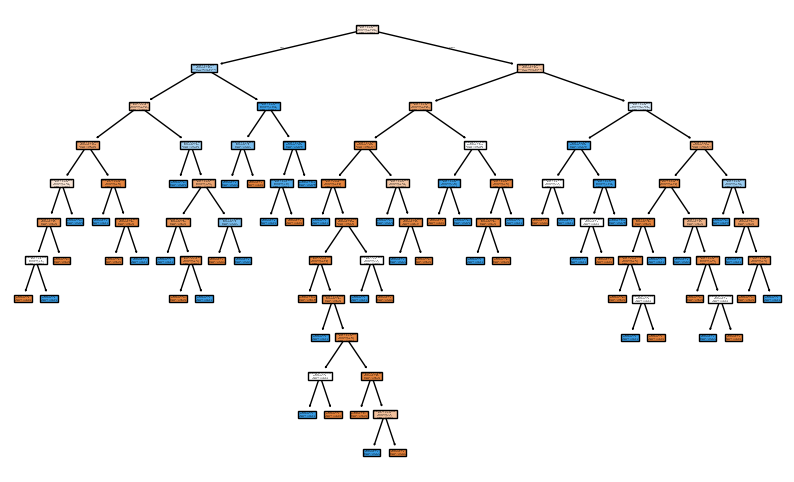

In [ ]:
# Save unpruned Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(10, 6))
plot_tree(dt_model, feature_names=[f"Feature {i}" for i in range(X.shape[1])], class_names=["Class 0", "Class 1"], filled=True)
plt.show()

Cross-Validation Accuracy Scores: [0.935 0.89  0.905 0.94  0.925]
Mean Accuracy: 0.9190

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       555
         1.0       0.91      0.91      0.91       445

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



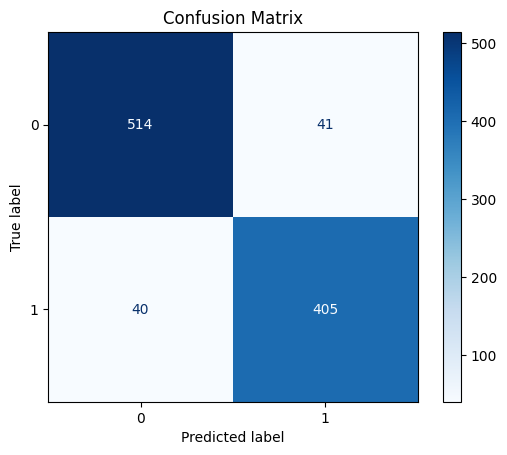

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred = cross_val_predict(dt_model, X, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

As we can see, the decision tree outperforms all other models. As expected, the second-best performing model is a SVM with RBF kernel. The logistic regression, LDA, QDA, and Linear SVM suffer from their assumption about the linear (QDA: quadratic) property of the data. The decision tree with a maximum depth of 2 cannot capture the complexity of the hierarchical rules. When fitting the data, we could observe the following properties:
*   Less irrelevant features decrease the performance difference between the decision tree and the SVM with RBF kernel (decision trees are better at feature selection)
*   More noise decreases the performance difference between the decision tree and the other models (unpruned decision trees are prone to overfitting)
*   Less hierarchical rules decrease the performance difference between the decision tree and the other models

### 4.3 Implementation on Real Dataset

A real dataset, for which the unpruned decision tree is exceptionally well-suited is the Chess (King-Rook vs. King-Pawn) Dataset (Shapiro, 1983). It originates from endgame scenarios in chess, where one player has a King and Rook (KR), while the other has a King and Pawn (KP). The objective is to predict whether the player with King and Rook can force a win or not. The dataset is a typical decision tree scenario due to the following properties:

*   Rule-Based Nature: Chess endgames follow strict rules, making it easy for a Decision Tree to split data logically
*   Nonlinear Relationships: The dataset has complex interactions (e.g., pinning, zugzwang), where linear models could struggle
*   Hierarchical Decision-Making: Decision Trees can naturally mimic game logic and conditions

In [ ]:
# fetch dataset
chess_king_rook_vs_king_pawn = fetch_ucirepo(id=22)

# data (as pandas dataframes)
X = chess_king_rook_vs_king_pawn.data.features
y = chess_king_rook_vs_king_pawn.data.targets

X.head()

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,skewr,skrxp,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos
f,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n
f,f,f,f,t,f,f,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n
f,f,f,f,t,f,t,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n
f,f,f,f,f,f,f,f,t,f,f,...,f,f,f,f,f,f,f,t,t,n
f,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n


The features represent different positional and strategic attributes of the chessboard in a given game state. Each column represents a specific board feature, and each row represents a particular game position. For example, the first feature (bkblk) describes if the black king is blocked (f = no, t = yes).

In [ ]:
y.head()

,wtoeg
f,won
f,won
f,won
f,won
f,won


The target variable describes whether the game was won by the player with King and Rook.

In [ ]:
# One-Hot Encoding of Categorical Features
X_encoded = pd.get_dummies(X)  # Convert categorical columns into numerical features

# Define models
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000),  # Increased iterations to avoid convergence issues
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_encoded, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_results[name] = cv_scores.mean()  # Store mean accuracy

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.955
Decision Tree with maximum depth of 2: 0.713
Logistic Regression: 0.924
LDA: 0.888
QDA: 0.621
Linear SVM: 0.920
RBF SVM: 0.924


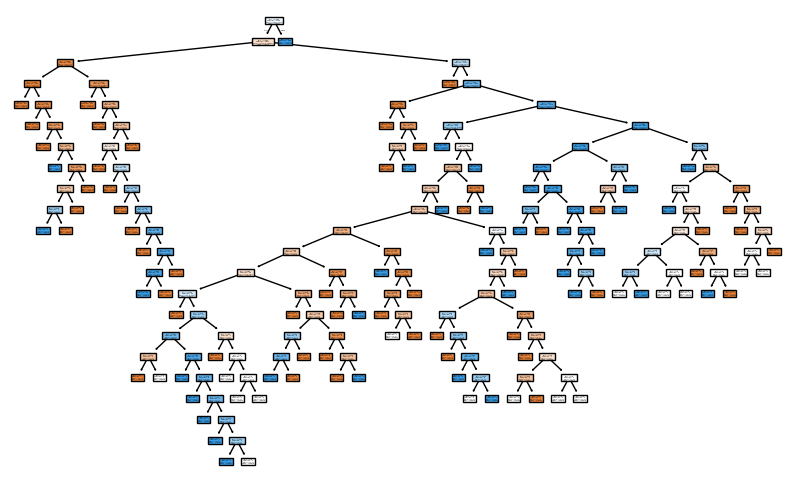

In [ ]:
# Save unpruned Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_encoded, y)

# Plot the decision tree
plt.figure(figsize=(10, 6))
plot_tree(dt_model, feature_names=[f"Feature {i}" for i in range(X_encoded.shape[1])], class_names=["Class 0", "Class 1"], filled=True)
plt.show()

Cross-Validation Accuracy Scores: [0.9859375  0.98904538 0.98435055 0.97496088 0.97496088]
Mean Accuracy: 0.9819

Classification Report:
              precision    recall  f1-score   support

       nowin       0.98      0.98      0.98      1527
         won       0.98      0.98      0.98      1669

    accuracy                           0.98      3196
   macro avg       0.98      0.98      0.98      3196
weighted avg       0.98      0.98      0.98      3196



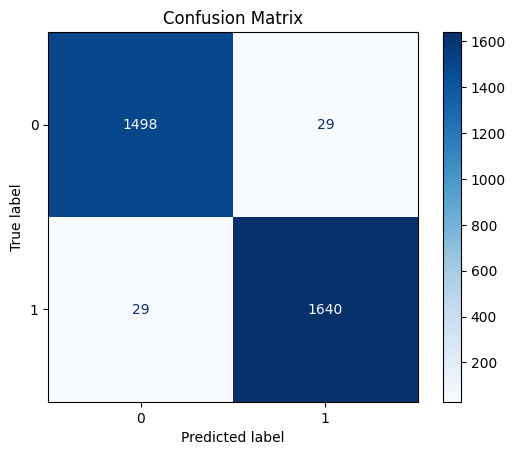

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(dt_model, X_encoded, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred = cross_val_predict(dt_model, X_encoded, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

As we can see, the unpruned tree has a very large depth. Nonetheless, it does not seem to overfit as indicated by the high accuracy and F1 score in cross-validation. With an accuracy of 95.5% it greatly outperforms the decision tree with a maximum depth of 2 as well as most of the other models. The best-performing models after the decision tree are the SVM (with both linear and RBF kernel) as well as the logistic regression. In contrast to these results, the second-best performing model on the artificial dataset was the SVM with RBF kernel - on the artificial dataset, the SVM with linear kernel and logistic regression performed worse by far. This indicates that, despite the hierarchical rule-based nature of chess, the data can be represented well by linear relationships.

## 5. Decision tree with a maximum depth of 2

A decision tree without pruning is allowed to grow freely, making splits based on the features until all data points are perfectly classified or until other stopping criteria are met (Blockeel et al., 2023). This results in a complex tree that can easily overfit the data, capturing noise and minor patterns. In contrast, a decision tree with a maximum depth of 2 is restricted to making at most two levels of splits, leading to a much simpler model. This limits the tree's ability to capture intricate patterns, potentially underfitting the data but reducing the risk of overfitting and improving generalization on unseen data (Blockeel et al., 2023).

### 5.1 Assumptions of Decision Tree

The assumptions of a decision tree can be found in section 4.1. The only difference for the decision tree with a maximum depth of two is that it is assumed that the relationship between the independent variables and the target variable can be captured with two levels of splits.

### 5.2 Implementation on Artificial Dataset

As described in Section 4.2, the data must not follow a linear distribution and instead hierarchical rules to ensure that the decision tree outperforms the other models. Considering that we now want to achieve the most superior performance with a decision tree of depth two, we should only introduce one hierarchical rule (otherwise the tree cannot capture the relationship). The other difference is that we will add more noise since an pruned tree is less likely to overfit.

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate a hierarchical dataset
n_samples = 1000
X = np.random.rand(n_samples, 15)  # 15 features, but some will be irrelevant to worsen RBF SVM performance
y = np.zeros(n_samples)

# Introduce one hierarchical rules
y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1

# Add relatively high amount of noise since pruning makes decision trees less prone to overfitting
# and worsens the performance of the other models
y[np.random.choice(n_samples, size=150, replace=False)] = 1 - y[np.random.choice(n_samples, size=150, replace=False)]

# Train classifiers
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_results[name] = cv_scores.mean()  # Store the mean of cross-validation scores

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.759
Decision Tree with maximum depth of 2: 0.882
Logistic Regression: 0.813
LDA: 0.821
QDA: 0.798
Linear SVM: 0.822
RBF SVM: 0.825


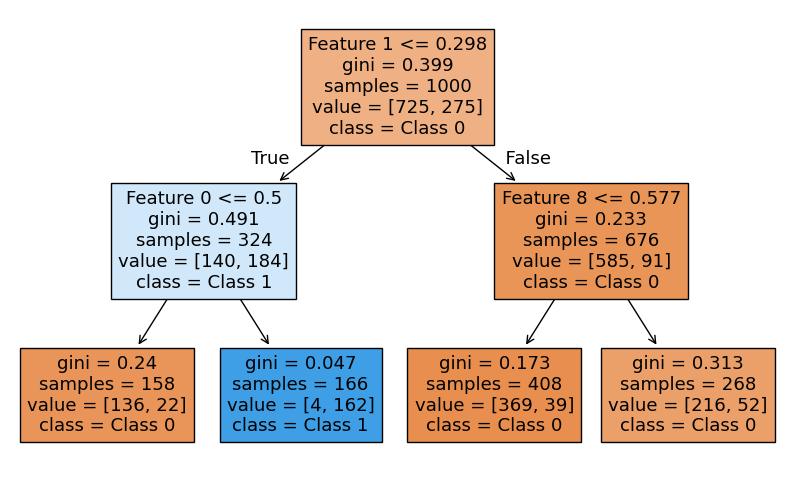

In [ ]:
# Save Decision Tree with max depth of 2
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(10, 6))
plot_tree(dt_model, feature_names=[f"Feature {i}" for i in range(X.shape[1])], class_names=["Class 0", "Class 1"], filled=True)
plt.show()

Cross-Validation Accuracy Scores: [0.91  0.875 0.9   0.87  0.85 ]
Mean Accuracy: 0.8810

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       725
         1.0       0.97      0.59      0.73       275

    accuracy                           0.88      1000
   macro avg       0.92      0.79      0.83      1000
weighted avg       0.89      0.88      0.87      1000



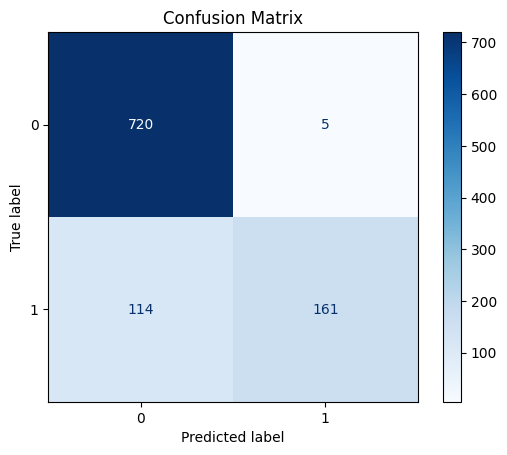

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred = cross_val_predict(dt_model, X, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

It can be seen that the tree outperforms the other models by far. The decision tree with a depth of two achieves 88.2% of accuracy, the second-best performing model is the SVM with RBF kernel with an accuracy of 82.5%. We can make the following observations here:
*   The decision tree without pruning performs the worst although the data follows a hierarchical rule, which could theoretically be easily captured by any decision tree - this shows how unpruned trees easily overfit data and describe patterns that do not exist
*   The linear models show a superior performance than in the dataset of Section 4 which included a set of hierarchical rules, showing that a model of which the assumptions are not met may still predict relatively well if the data is not based on complex relationships
*   More noise increases the performance difference between the tree and the other models
*   More hierarchical rules make the unpruned tree outperform the pruned tree
*   Less irrelevant features decrease the performance difference between the tree and the SVM with RBF kernel

The pre-defined hierarchical rule is well captured in the left branch of the tree. The root node splits on Feature 1, aligning with the rule. The rightmost leaf in this branch, with a low Gini index (0.024), consists almost entirely of Class 1 samples, confirming the rule’s effect. The right branch, which splits on Feature 6, does not follow the hierarchical rule and reflects noise, as seen in its higher Gini index (0.495).



### 5.3 Implementation on Real Dataset

A real dataset, for which a Decision Tree with a maximum depth of 2 is exceptionally well-suited, is the Titanic Survival Dataset (YasserH, 2023). It originates from historical passenger data on the Titanic, where the objective is to predict whether a passenger survived based on key attributes such as class, age, and gender. The dataset is ideal for a shallow Decision Tree due to the following properties:  

* Strong Hierarchical Structure: Survival rates follow a clear hierarchy, with gender, age and class being the most decisive factors.  
* Nonlinear Relationships: Interactions between variables, such as women in higher classes having the highest survival rates, are difficult for linear models to capture.  
* Simple yet Effective Splits: A depth-2 tree can separate most of the data by splitting on gender and then on class or age, making it highly interpretable and effective.

In [ ]:
# Load dataset
df = pd.read_csv("titanic.csv").dropna()

# Define features and target
features = ['Pclass', 'Sex', 'Age', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
target = 'Survived'

# Extract X and y
X = df[features].copy()
y = df[target]

# Encode categorical columns
label_encoders = {}
for col in X.select_dtypes(include=['object', 'category']):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

X_encoded = X

# Train classifiers
models = {
    "Decision Tree without Pruning": DecisionTreeClassifier(random_state=42),
    "Decision Tree with maximum depth of 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Perform cross-validation and collect results
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_encoded, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_results[name] = cv_scores.mean()  # Store the mean of cross-validation scores

# Print cross-validation results
print("Cross-Validated Accuracy")
for model, mean_acc in cv_results.items():
    print(f"{model}: {mean_acc:.3f}")

Cross-Validated Accuracy
Decision Tree without Pruning: 0.732
Decision Tree with maximum depth of 2: 0.753
Logistic Regression: 0.753
LDA: 0.743
QDA: 0.743
Linear SVM: 0.737
RBF SVM: 0.672


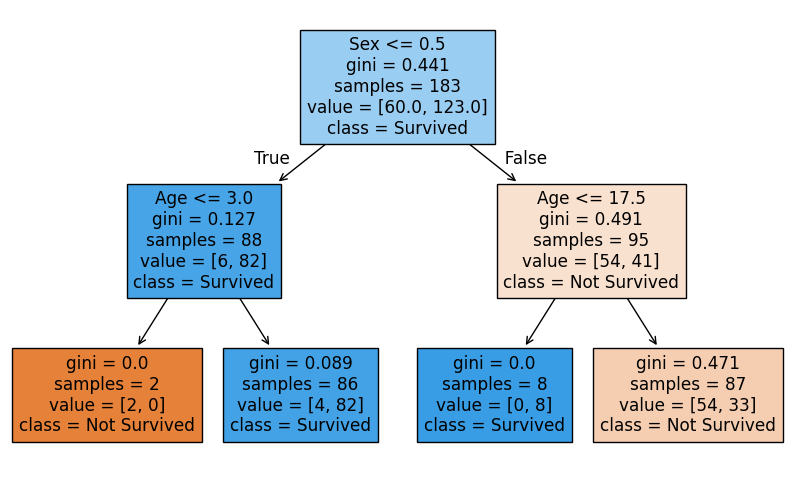

In [ ]:
# Save Decision Tree with max depth of 2
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X_encoded, y)

# Plot the decision tree
plt.figure(figsize=(10, 6))
feature_names = X_encoded.columns.tolist()
plot_tree(dt_model, feature_names=feature_names, class_names=["Not Survived", "Survived"], filled=True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.58      0.60        60
           1       0.80      0.83      0.82       123

    accuracy                           0.75       183
   macro avg       0.71      0.71      0.71       183
weighted avg       0.74      0.75      0.75       183



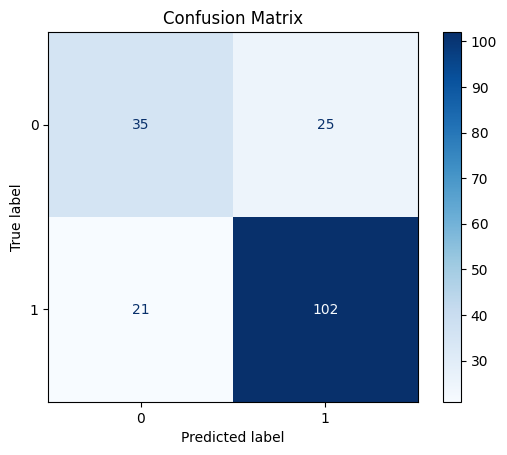

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(dt_model, X_encoded, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

We can see that the decision tree with a maximum depth of 2 slightly outperforms the other models, achieving the same accuracy as the logistic regression with 75.3%. The performance differences are, however, minor. The worst-performing model is the SVM with RBF kernel with an accuracy of 67.2%. Nonetheless, among six tested datasets, the Titanic dataset produced the greatest outperformance by the decision tree with a maximum depth of 2. This shows that there are only few cases in the real world, in which the relationships are so easy that they can be modelled well by a decision tree with a maximum depth of 2.

In the case of the Titanic dataset, the decision tree suggests that sex and age were key factors in survival probability. The root split on sex indicates that females (Sex <= 0.5) had a much higher survival rate than males. Males (Sex > 0.5) had a lower survival rate, especially older individuals (Age > 17.5). This pattern reflects that priority was given to women and children, while many adult men were left behind.

The fact that the decision tree achieves a high accuracy and F1 score solely based on these two features suggests that the "women and children first" policy overshadowed other features, such as the class to which the passenger belonged.

## 6. Linear Support Vector Machine (SVM)
A Support Vector Machine (SVM) is a classification algorithm designed to separate data points into distinct classes (Shah, 2022). A linear SVM constructs a hyperplane that best separates the classes while maximizing the margin between them. Among the infinitely many possible hyperplanes, the optimal one is chosen based on the maximum margin principle. The data points closest to this hyperplane, known as support vectors, determine its position and orientation. In the case of a linear SVM, the decision boundary is a straight line in a two-dimensional space (Shah, 2022).

### 6.1 Assumptions

The assumptions of a linear SVM are the following (Cristianini & Shawe-Taylor, 2000):

* **Linearly Separable Data**: The data is or can be transformed into a linearly separable space.
* **Kernel Transformation**: If the data is not linearly separable, a kernel SVM is used to transform the data into a higher-dimensional space where separation is possible.
* **Margin Maximization**: The best decision boundary is the one that maximizes the margin (distance) between the closest points of different classes (support vectors).








### 6.2 Implementation on Artificial Dataset

To create an artificial dataset where a Linear SVM performs optimally while more complex models struggle, we designed a dataset with nearly perfect linear separability.  

The key characteristics of this dataset are:  
* **Linear (or almost linear) Class Boundaries**: Linear SVM excels when classes are well separated by a hyperplane, while more complex models may overfit or struggle to generalize.  
* **High Feature Informativeness**: Most features contribute meaningfully to classification, reducing ambiguity for a linear decision boundary.  
* **Minimal Noise and Clear Class Separation**: With a clear class separation and only a limited amount of noise, the dataset ensures that a linear decision function can easily distinguish between classes.  
* **Redundant Features for Complexity**: Redundant features primarily challenge non-linear models rather than affecting the Linear SVM’s performance as non-linear models are more prone to overfit.  

This dataset is ideal for a Linear SVM, as it provides a clear decision boundary with minimal overlap between classes, reinforcing the model’s strengths while limiting the advantages of more flexible, non-linear classifiers.

The dataset consists of 200 samples and 15 features. After generation, we applied feature normalization using StandardScaler.

Accuracy of Linear SVM on artificial dataset: 0.97

Classification Report for Linear SVM:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



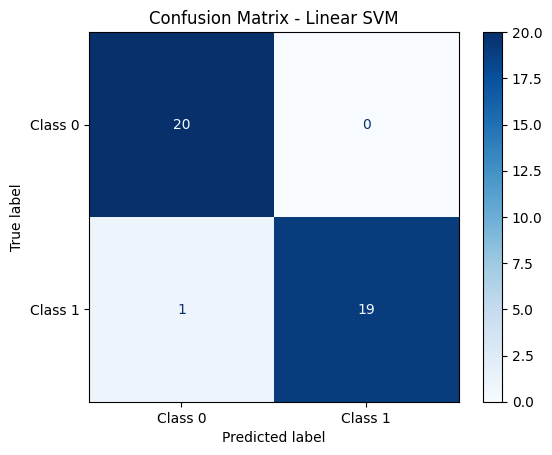

In [ ]:
# Creating an artificial dataset perfect for Linear SVM
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=15,  # High number of features
    n_classes=2,
    n_clusters_per_class=1,
    n_redundant=10,  # Higher redundant features to confuse non-linear models
    n_informative=3,
    flip_y=0.1,  # Reduced noise (10%) to avoid too much complexity
    class_sep=1.5,  # Slightly increased class separation to make it easier for linear models
    random_state=42
)

# Transforming into DataFrame
df_linear = pd.DataFrame(X_linear, columns=[f'Feature{i+1}' for i in range(X_linear.shape[1])])
df_linear['Target'] = y_linear

# Separating into train and test sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    df_linear.drop(columns='Target'), df_linear['Target'], test_size=0.2, random_state=42
)

# Normalization
scaler = StandardScaler()
X_train_linear = scaler.fit_transform(X_train_linear)
X_test_linear = scaler.transform(X_test_linear)

# Creating Linear SVM model
svm_linear = SVC(kernel='linear', probability=True)

# Training the model
svm_linear.fit(X_train_linear, y_train_linear)

# Making predictions
y_pred_linear = svm_linear.predict(X_test_linear)

# Evaluating the model
accuracy_linear = accuracy_score(y_test_linear, y_pred_linear)
print(f"Accuracy of Linear SVM on artificial dataset: {accuracy_linear:.2f}")
print("\nClassification Report for Linear SVM:\n", classification_report(y_test_linear, y_pred_linear))

# Confusion matrix
cm_linear = confusion_matrix(y_test_linear, y_pred_linear)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=["Class 0", "Class 1"])
disp_linear.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

The Linear SVM model demonstrates outstanding performance, achieving an accuracy of 97%, indicating that it correctly classifies 97% of instances.

A mean F1-score of 0.97 highlights a well-balanced trade-off between precision and recall, ensuring robust classification across both classes.

Notably, the model excels in predicting class 1, with a precision of 100%, meaning that every instance predicted as class 1 is indeed correct. The recall for class 1 is 95%, signifying that a small fraction is misclassified as class 0.

For class 0, the model achieves a precision of 95% and a recall of 100%, ensuring that all actual class 0 instances are correctly identified, with no false negatives.

Overall, the Linear SVM shows excellent performance when dealing with linearly separable data, achieving high accuracy and maintaining an impressive balance between precision and recall. However, the model might still struggle in scenarios where the data is more complex and not linearly separable, as it lacks the flexibility to create non-linear decision boundaries like models such as RBF SVM or Decision Trees.

In [ ]:
# Train classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Cross-validation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_linear, y_linear, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
Linear SVM: 0.945
Logistic Regression: 0.935
RBF SVM: 0.935
Decision Tree (Max Depth=2): 0.925
Decision Tree: 0.915
LDA: 0.900
QDA: 0.890


In comparison to the performance of other models, we can conclude that the Linear SVM leads with 94.5% accuracy, outperforming the other models, proving to be the best fit for this dataset.
RBF SVM and Logistic Regression are close with an accuracy of 93.5%. This could be expected considering that the linearity assumption of the Logistic Regression can be fulfilled by the linearly separable data. The fact that the RBF SVM does not outperform the Linear SVM is due to linearly separable data, which makes non-linear transformations unnecessary. Instead, the RBF SVM is likely to capture more noise. LDA (90%) and QDA (89%) perform the worst, as the class distributions may not be well captured by quadratic or linear decision boundaries.

Some influences on the model's performance we could observe are:
* More instances: improves performance of the linear SVM, as long as the data is linear
* Noise: affects all models, but the performance of the linear SVM was more strongly decreased than the performance of other models
* Feature selection: Better feature relevance improves Linear SVM's performance

### 6.3 Implementation on Real Dataset

A real dataset, which is well suited for the linear SVM is the Breast Cancer Wisconsin Dataset, which can be found in the UCI Machine Learning Repository (Wolberg, Mangasarian, Street, & Street, 1993).

The dataset contains data regarding breast cancer tumors. Features include, for example, size, texture, and symmetry. The target variable indicates if the tumor is benign (0) or malignant (1).

It is an ideal dataset for the Linear SVM because the classes are well separated by few features, meaning that the 2 types of tumors have different patterns.

The linear separability assumption is reasonable, since benign tumors tend to have low values in certain features, while malignant ones tend to have higher values.

In [ ]:
from sklearn.datasets import load_breast_cancer

# Loading breast cancer Wisconsin dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the training and testing data separately
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train classifiers for the real dataset
models = {
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "LDA": LDA(),
    "QDA": QDA()
}

# Cross-validation and evaluation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
RBF SVM: 0.970
Linear SVM: 0.967
LDA: 0.957
QDA: 0.955
Decision Tree (Max Depth=2): 0.940
Decision Tree: 0.925


Although the dataset aligns well with the assumptions of the linear SVM, it is  outperformed by a RBF SVM.
This indicates that the dataset is not perfectly linearly separable and the model profits from transforming the data into a higher dimensional space. Nonetheless, the separability appears to be close to linear considering the accuracy of 96.7% of the linear SVM.


Classification Report - Linear SVM (Breast Cancer)
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



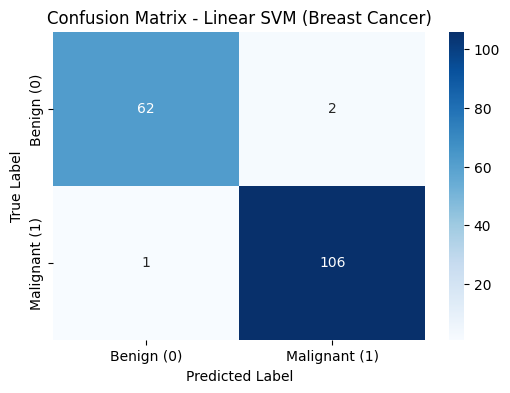


Cross-Validation Accuracy Scores (Linear SVM): [0.9875     0.9375     0.975      0.96202532 0.97468354]
Mean Accuracy (Linear SVM): 0.9673417721518988


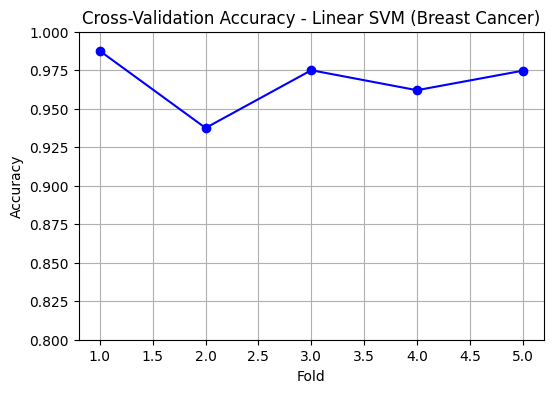

In [ ]:
# Testing the Linear SVM performance on the test set
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

# Metrics of evaluation for the Linear SVM
print("\nClassification Report - Linear SVM (Breast Cancer)")
print(classification_report(y_test, y_pred))

# Confusion matrix for the Linear SVM
cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Linear SVM (Breast Cancer)")
plt.show()

# Cross-validation accuracy using the Linear SVM
cv_scores_linear_svm = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores (Linear SVM):", cv_scores_linear_svm)
print("Mean Accuracy (Linear SVM):", np.mean(cv_scores_linear_svm))

# Plotting cross-validation scores for Linear SVM
plt.figure(figsize=(6, 4))
plt.plot(range(1, 6), cv_scores_linear_svm, marker='o', linestyle='-', color='blue')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy - Linear SVM (Breast Cancer)")
plt.ylim(0.8, 1)
plt.grid()
plt.show()

The model demonstrated high precision (0.98) and recall (0.99) for malignant tumors, indicating its strong ability to correctly identify malignant cases while minimizing false negatives. Similarly, for benign tumors, the model maintained a precision of 0.98 and recall of 0.97, reflecting its effectiveness in distinguishing benign cases with few misclassifications.

The accompanying plot illustrates the model's accuracy across multiple cross-validation folds. The accuracy remains consistently high, fluctuating between 0.9375 and 0.9875, suggesting that the model generalizes well across different subsets of the data. As the plot shows, the model is relatively stable.

## 7. Radial Basis Function Support Vector Machine (RBF SVM)
The RBF SVM is designed to handle complex classification and regression tasks. Unlike a linear SVM, which assumes that data can be separated by a straight line (or a hyperplane in higher dimensions), an RBF SVM can model intricate decision boundaries by mapping the input data into a higher-dimensional space using a non-linear transformation (Eskandar, 2023). This is achieved through the RBF kernel, which measures similarity between data points based on their distance in the feature space. As a result, RBF SVMs are particularly effective for datasets where class boundaries are not well-defined linearly, making them well-suited for high-dimensional and non-linearly separable problems (Eskandar, 2023).

### 7.1 Assumptions

The assumptions of an RBF SVM are the following (Shah, 2022):

* **Non-Linearly Separable Data**: The data is not linearly separable and requires a transformation to a higher-dimensional space for better separation.
* **Margin Maximization**: The best decision boundary is the one that maximizes the margin (distance) between the closest points of different classes (support vectors).
* **Flexibility for Non-Linear Data**:  The RBF kernel provides greater flexibility for handling non-linear data by mapping it into a higher-dimensional space, where a linear hyperplane can better separate the classes. This allows the model to capture complex patterns that would not be separable in the original feature space.
* **Kernel Parameters**: The RBF kernel depends on the γ (gamma) parameter, which controls how much influence a single data point has, and the regularization parameter C, which balances margin maximization and classification error.


### 7.2 Implementation on Artificial Dataset

To create an artificial dataset that favors non-linear classification methods, we generated a non-linear dataset using make_moons(), which produces two interleaving moon-shaped clusters. This structure presents an ideal scenario for an RBF SVM, as its kernel can effectively map the non-linearly separable data into a higher-dimensional space for better classification.

The key characteristics of the dataset are:

* **Inherent Non-Linearity**: The interleaving moon-shaped clusters make it difficult for linear classifiers to find a suitable decision boundary, favoring models with non-linear capabilities such as the RBF SVM
* **Feature Standardization**: The features were standardized using StandardScaler to enhance RBF SVM performance. RBF SVM relies on Euclidean distance in its kernel function, making it highly sensitive to feature scales; without standardization, features with larger magnitudes dominate, distorting the decision boundary. In contrast, models like Decision Trees are scale-invariant, while linear models (Logistic Regression, LDA, Linear SVM) are mainly affected in terms of convergence speed rather than decision boundary distortion. Hence, Feature Standardization was crucial to ensure that the RBF SVM outperforms the other models.

Since RBF SVM is excellent at capturing complex, non-linear decision boundaries, it significantly outperforms other models on this dataset, making this artificial dataset perfectly suitable for the RBF SVM model.

Cross-Validation Accuracy Scores: [0.96 0.96 0.98 0.96 0.99]
Mean Accuracy: 0.9700

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       250
           1       0.98      0.96      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



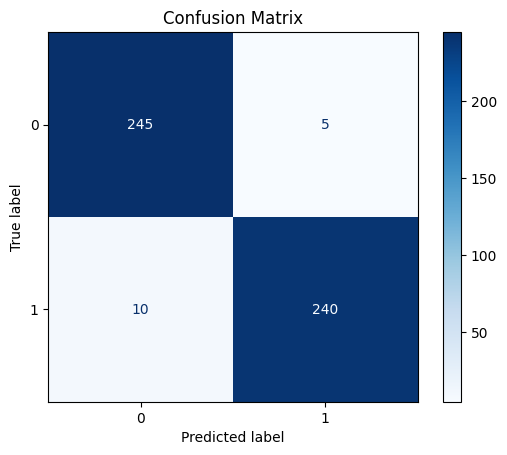

In [ ]:
# Creating an artificial non-linear dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)  # increased sample size & noise to outperform other models

# Normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Fitting the model
svm = SVC(kernel="rbf")

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(svm, X, y, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

y_pred = cross_val_predict(svm, X, y, cv=cv)

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


The model demonstrates strong and consistent performance, achieving an average cross-validation accuracy of 97%, with scores ranging from 96% to 99%, indicating reliable generalization across different folds. The classification report confirms this, with high precision (0.96–0.98) and recall (0.96–0.98) for both classes, resulting in a balanced F1-score of 0.97. These results highlight the model’s ability to accurately distinguish between the two classes, minimizing both false positives and false negatives while maintaining robust overall performance.


In [ ]:
# Train classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Cross-validation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

# Print results
print("\nCross-Validated Accuracy")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy
RBF SVM: 0.976
Decision Tree: 0.964
Decision Tree (Max Depth=2): 0.916
QDA: 0.860
Logistic Regression: 0.858
LDA: 0.858
Linear SVM: 0.852


The RBF SVM outperformed all other models with a cross-validated accuracy of 97.6%, followed by the Decision Trees (96.4% and 91.6%) and Logistic Regression (86%). The linear SVM performed worst with an accuracy of 85.4%. These results show how the moon-shaped distribution of the data challenges the models with assumptions about linearity and normality. The only model which comes close to the RBF SVM performance is the decision tree, which benefits from being non-parametric and, therefore, more flexible to adapt to the moon-shaped data distribution.

When fitting the data, we could observe the following properties:
* More instances increase RBF SVM's advantage over Linear SVM
* For a very high amount of noise, the other models outperform the RBF SVM despite the non-linear data structure - this is because the RBF SVM decision boundary can become overly complex and capture noise
* RBF SVM handles irrelevant features better than other models
* Higher dataset complexity in terms of more features favors RBF SVM

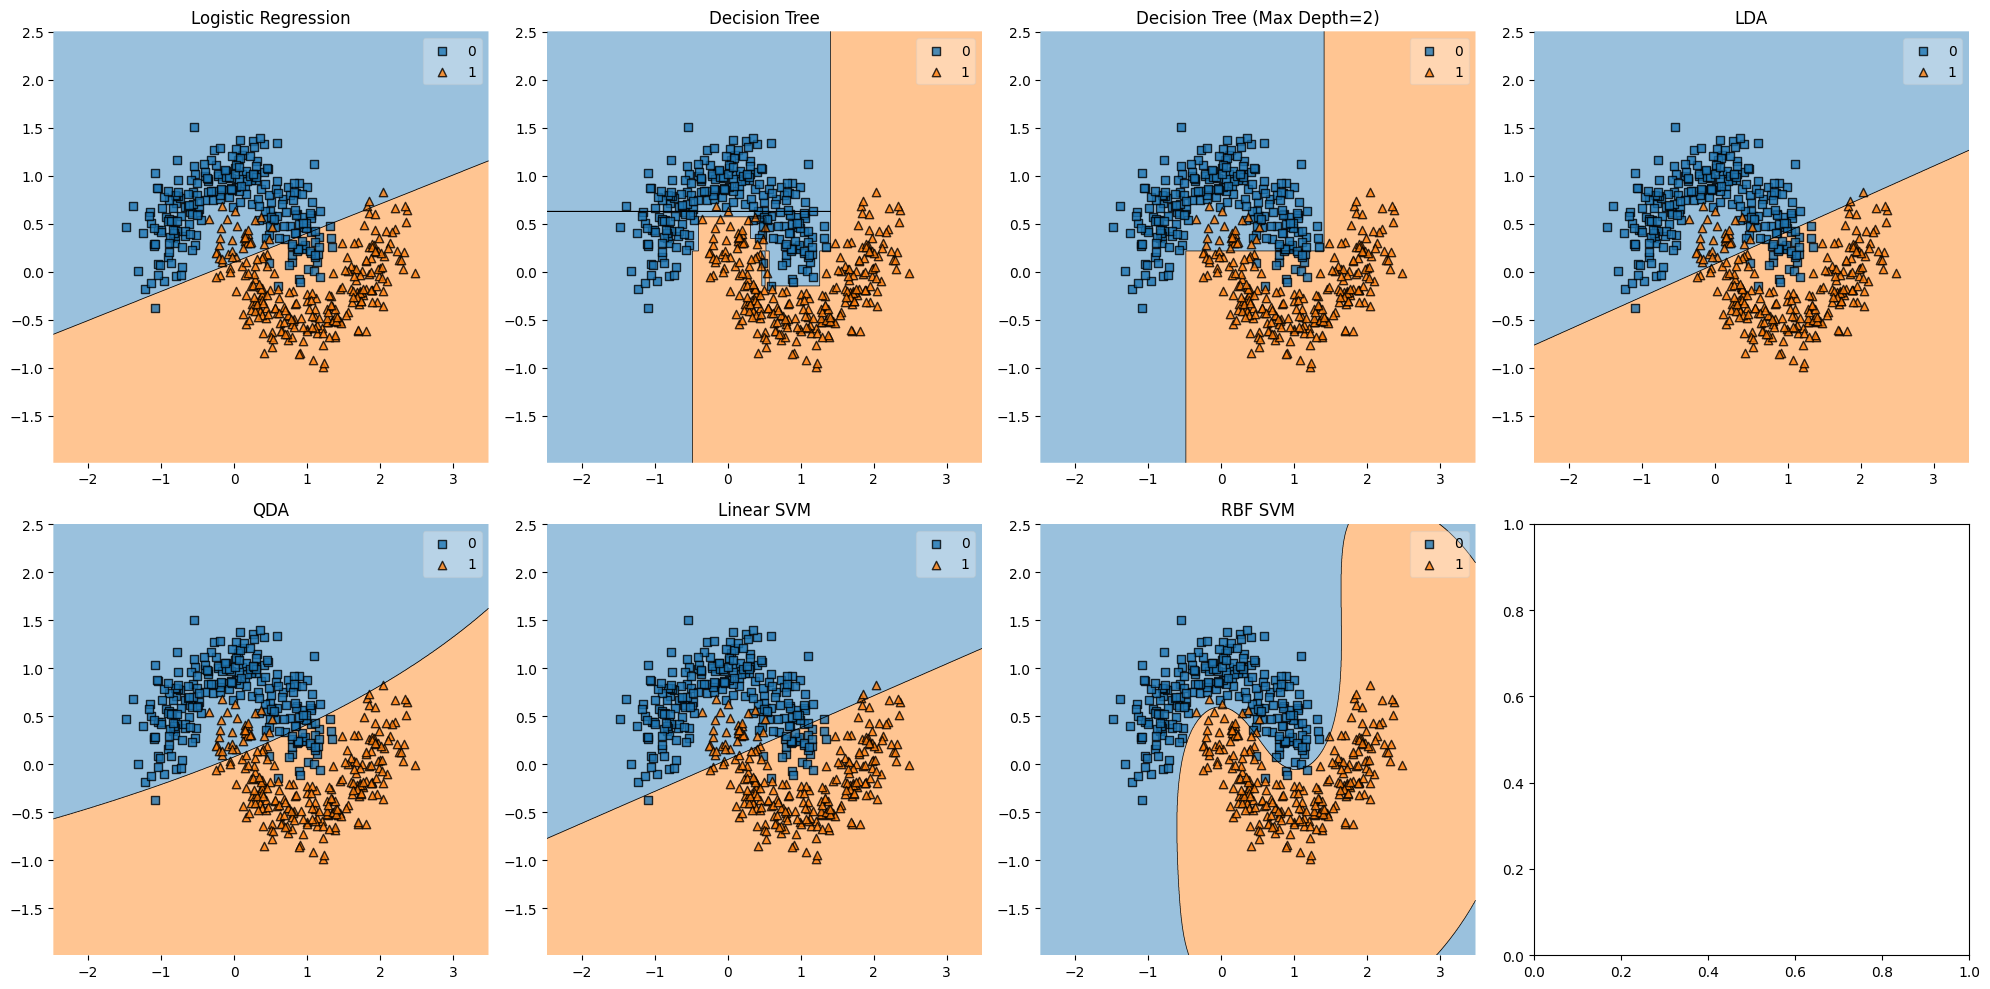

In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "LDA": LDA(),
    "QDA": QDA(),
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf")
}

# Fit models
fitted_models = {name: model.fit(X, y) for name, model in models.items()}

# Plot decision boundaries
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows, 4 columns

for ax, (name, model) in zip(axes.flatten(), fitted_models.items()):
    plot_decision_regions(X, y, clf=model, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Visualizing the decision boundaries makes clear why the RBF SVM outperforms the other models. Unlike the linear models (Logistic Regression, Linear SVM, LDA, and QDA) which use straight lines to separate the classes, the RBF SVM creates a curved boundary that follows the natural separation between the two classes. This allows it to correctly classify more of the points that fall in areas where the classes overlap or have irregular shapes. The standard Decision Tree and Decision Tree with max depth of 2 can adapt a lot better than the linear models to the data. Nonetheless, they show more rigid, axis-aligned boundaries, which do not perform as well as the RBF SVM's smooth, adaptive boundary for this particular dataset.

### 7.3 Implementation on Real Dataset
A real dataset well-suited for a RBF SVM is the Banknote Authentication Dataset (Lohweg, 2012). The dataset contains features extracted from images of real and fake banknotes, collected from statistical variations in their visual components. The goal is to predict whether a banknote is real (class = 0) or fake (class = 1).

It is an ideal dataset for a RBF SVM since the data is not linearly separable. Some fake banknotes are very similar to real ones, requiring a more flexible model. Transforming the space with a non-linear kernel helps capture subtle patterns in the data distribution.

Classification Report - SVM RBF (Banknote Authentication)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



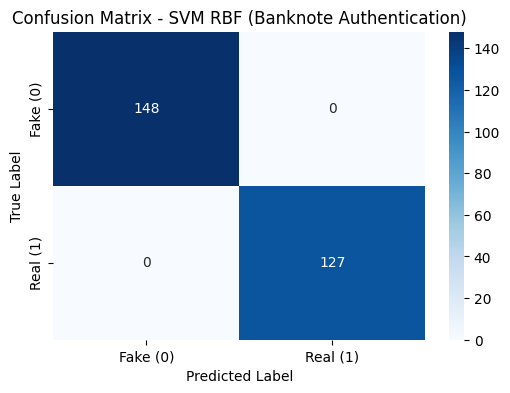

In [ ]:
from sklearn.model_selection import cross_val_score

# loading banknote auth dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
column_names = ["variance", "skewness", "curtosis", "entropy", "class"]
df = pd.read_csv(url, names=column_names)

# separating features and target
X = df.drop("class", axis=1)
y = df["class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train test splitting
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# training SVM with RBF kernel
model = SVC(kernel='rbf', gamma='scale', C=1.0)
model.fit(X_train, y_train)

# predicting
y_pred = model.predict(X_test)

# metrics for evaluation of the model
print("Classification Report - SVM RBF (Banknote Authentication)")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plotting consufion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM RBF (Banknote Authentication)")
plt.show()

Even with a training-test split, in which the RBF SVM is confronted with completely unseen data, the model achieves 100% accuracy. This means all of the banknotes were classified correctly - the fake ones as well as the real ones.

Cross-Validation Accuracy Scores: [1.         1.         0.99543379 1.         1.        ]
Mean Accuracy: 0.9990867579908675


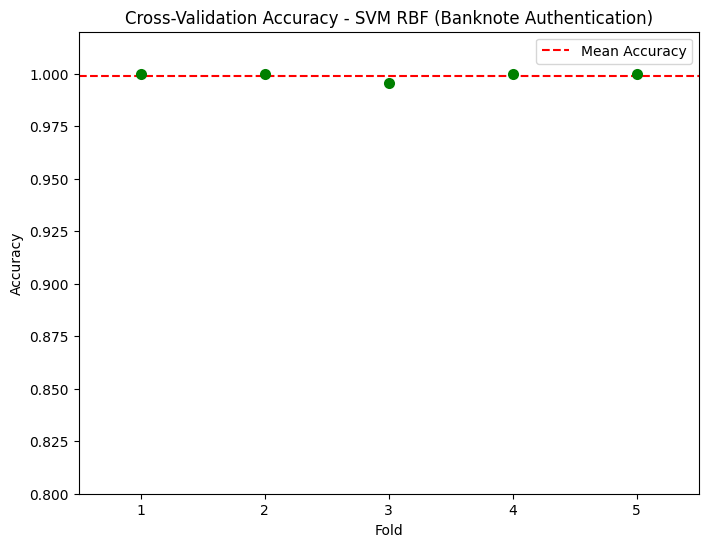

In [ ]:
# cross-validation accuracy
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))

# visualizing
plt.figure(figsize=(8, 6))
sns.stripplot(x=np.arange(1, len(cv_scores) + 1), y=cv_scores, jitter=0.1, color="green", size=8) # added jitter to prevent overlapping points

plt.axhline(y=np.mean(cv_scores), color="red", linestyle="--", label="Mean Accuracy")
plt.ylim(0.8, 1.02)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy - SVM RBF (Banknote Authentication)")
plt.legend()
plt.show()

The plot visualizes the accuracy of the model on the different folds of five-fold cross validation. Also in terms of cross-validation, the accuracy is 1.0 for four out of five folds. This reinforces that a RBF SVM is a great fit for this dataset.

In [ ]:
# Train classifiers
models = {
    "Linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Decision Tree (Max Depth=2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
    "QDA": QDA()
}

# Perform cross-validation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = np.mean(cv_scores)

# Print results sorted by performance
print("\nCross-Validated Accuracy:")
for model, mean_acc in sorted(cv_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {mean_acc:.3f}")


Cross-Validated Accuracy:
RBF SVM: 0.999
QDA: 0.985
Linear SVM: 0.985
Decision Tree: 0.984
Logistic Regression: 0.981
LDA: 0.976
Decision Tree (Max Depth=2): 0.917


Since the RBF SVM achieves near-perfect accuracy (0.999), it outperforms all other models, making it the best choice for this dataset. QDA, Linear SVM, and Decision Tree perform similarly well (around 0.985), but slightly fall short of RBF SVM. This indicates that although the dataset cannot be perfectly modelled by linear models, it still has some linear properties. The Decision Tree with Max Depth=2 struggles the most, with accuracy at 0.917, indicating severe underfitting due to its limited depth. The data is too complex to be mapped by a shallow decision tree.

# 3. Bias Variance and Model Capacity

In this section, we explore the relationship between decision tree complexity, pruning, and the bias-variance tradeoff. Decision trees have flexible capacity: deep trees can fit complex patterns but may overfit, while heavily pruned trees generalize better but may underfit.

To analyze this tradeoff, we use a dataset where varying the number of observations impacts the optimal pruning level (ccp_alpha). We conduct the following steps:

* Dataset Selection and Modification: We introduce a varying number of instances to the dataset, affecting the decision boundary complexity. We determine the ideal pruning level (ccp_alpha) for different numbers of observations and visualize this relationship.
* Bias-Variance Decomposition: We compute bias and variance errors for three different versions of the dataset at multiple pruning levels (ccp_alpha).
* Interpretation of Results: We analyze how pruning influences model capacity, bias, variance, and overall error.

## Dataset Selection and Modification

As a starting point, we used the dataset that was used for unpruned decision tree in section 4. In this way, it is ensured that all of the assumptions of the decision tree are met. We explored the relationship between the optimal ccp_alpha and the following dataset features (code and results can be found in the appendix):
* level of noise
* number of instances
* number of features
* number of hierarchical rules
* proportion of classes

The ccp_alpha parameter controls the amount of pruning applied to the decision tree, with higher values leading to more aggressive pruning and smaller trees. To identify the optimal ccp_alpha, we utilized cross-validation to evaluate the performance of pruned decision trees across a range of potential ccp_alpha values, obtained using the cost_complexity_pruning_path method. This method provides a series of possible pruning levels, from minimal pruning (small ccp_alpha) to maximum pruning (large ccp_alpha). By computing the mean cross-validation score for each pruning level, we identified the ccp_alpha value that provided the best trade-off between bias and variance.

After experimenting with the different dataset parameters, it was observed that the number of instances exhibited the most consistent and clear relationship with the optimal ccp_alpha.

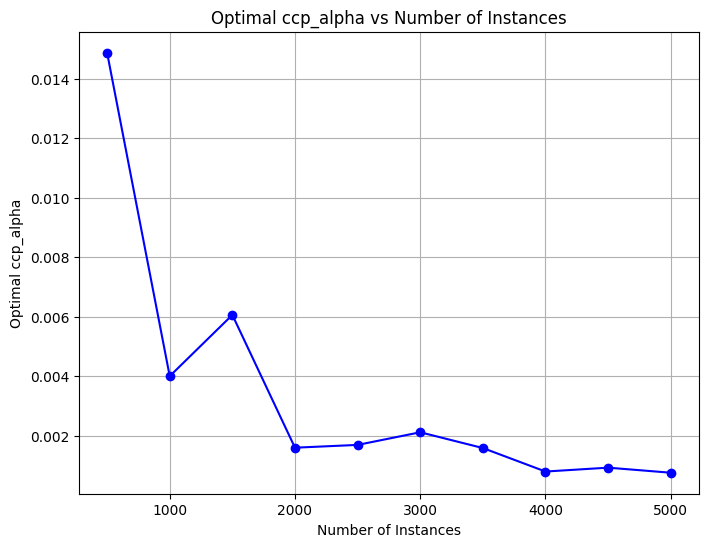

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Function to generate the hierarchical dataset from section 4  with the option of tweaking the number of instances
def generate_hierarchical_dataset(n_samples=1000, n_features=15):
    X = np.random.rand(n_samples, n_features)
    y = np.zeros(n_samples)

    # Introduce stepwise hierarchical rules
    y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1
    y[(X[:, 2] > 0.7) & (X[:, 3] < 0.5)] = 1
    y[(X[:, 4] < 0.2) & (X[:, 5] > 0.8)] = 1
    y[(X[:, 6] > 0.6) & (X[:, 7] < 0.4)] = 1
    y[(X[:, 8] < 0.1) & (X[:, 9] > 0.9)] = 1

    # Add noise
    y[np.random.choice(n_samples, size=20, replace=False)] = 1 - y[np.random.choice(n_samples, size=20, replace=False)]

    return X, y

# Function to find optimal ccp_alpha
def find_optimal_ccp_alpha(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Set up unpruned tree
    tree = DecisionTreeClassifier(random_state=42)
    # Get all possible ccp_alpha values
    path = tree.cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas

    scores = []
    # loop through ccp_alpha values and store the mean accuracy of the cross-validation
    for alpha in ccp_alphas:
        tree_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        cv_score = np.mean(cross_val_score(tree_pruned, X_train, y_train, cv=5))
        scores.append(cv_score)

    return ccp_alphas[np.argmax(scores)] if scores else 0

# Vary number of instances
n_samples_range = np.arange(500, 5001, 500)  # from 500 to 5000 instances
optimal_ccp_alphas = []

for n_samples in n_samples_range:
    X, y = generate_hierarchical_dataset(n_samples=n_samples)
    optimal_ccp_alphas.append(find_optimal_ccp_alpha(X, y))

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(n_samples_range, optimal_ccp_alphas, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Instances")
plt.ylabel("Optimal ccp_alpha")
plt.title("Optimal ccp_alpha vs Number of Instances")
plt.grid(True)
plt.show()

The plot shows that as the number of instances increases, the optimal level of pruning decreases exponentially (except for a small peak at n=1500, which might be due to the random noise in the dataset).

This illustrates a fundamental principle in machine learning: the relationship between model complexity and training data size. With small datasets, simple models (higher regularization) tend to perform better. As training data increases, more complex models become optimal because they can leverage the additional information without overfitting. This means that as the training data size increases, the risk of overfitting and the difference between training and test error of complex models decrease.

When you have fewer training examples (left side of the graph), the model needs more regularization to avoid overfitting, hence the higher optimal ccp_alpha. With limited data, complex trees would likely capture noise rather than true patterns, so pruning is essential.

As the number of instances increases, the model can afford to create more complex trees (lower ccp_alpha) because more data provides better estimates of the true underlying patterns. With more data, decision trees can avoid overfitting by splitting on more generalizable features instead of fitting to random fluctuations.

## Bias-Variance Decomposition

In [ ]:
from mlxtend.evaluate import bias_variance_decomp

# Set random seed for reproducibility
np.random.seed(42)

# Define the values for number of instances and corresponding optimal ccp_alpha from Task 1
instances_ccp_alpha = {
    500: optimal_ccp_alphas[0],
    2500: optimal_ccp_alphas[4],
    5000: optimal_ccp_alphas[-1]
}

# Store results in a DataFrame
results = []

for n_samples, ccp_alpha in instances_ccp_alpha.items():
    X, y = generate_hierarchical_dataset(n_samples=n_samples, n_features=15)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create decision tree with specific ccp_alpha
    tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Compute bias-variance decomposition
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        tree, X_train, y_train, X_test, y_test,
        loss='0-1_loss', random_seed=42
    )

    # Append results to list (including accuracy)
    results.append([n_samples, ccp_alpha, avg_bias, avg_var, avg_expected_loss])

# Convert results to a DataFrame
summary_df = pd.DataFrame(results, columns=["Number of Instances", "Optimal ccp_alpha", "Bias", "Variance", "Total Error"])
summary_df = summary_df.round(4)

# Display the table
print(summary_df)

   Number of Instances  Optimal ccp_alpha   Bias  Variance  Total Error
0                  500             0.0149  0.080    0.1066       0.1538
1                 2500             0.0017  0.030    0.0298       0.0518
2                 5000             0.0008  0.018    0.0189       0.0295


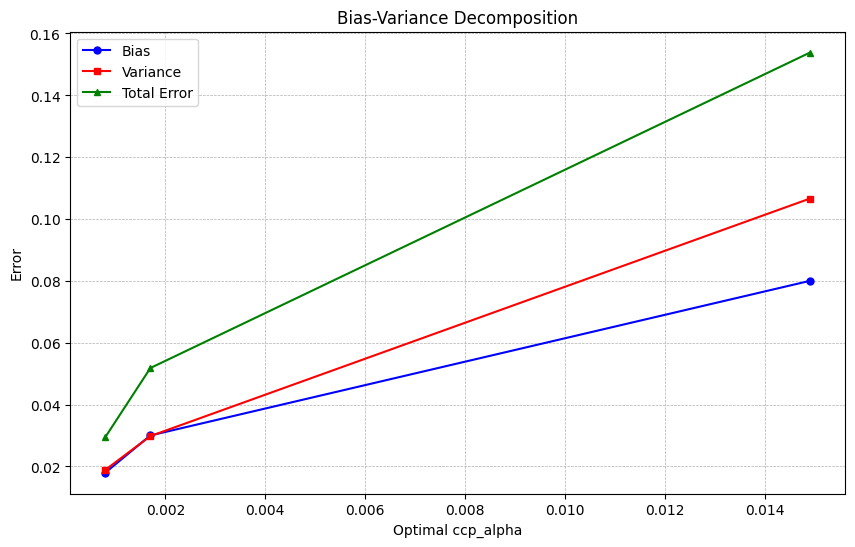

In [ ]:
# Plot the Bias-Variance-Decomposition
plt.figure(figsize=(10, 6))
plt.plot(summary_df["Optimal ccp_alpha"], summary_df["Bias"], marker='o', markersize=5,
         linestyle='-', label="Bias", color='blue')
plt.plot(summary_df["Optimal ccp_alpha"], summary_df["Variance"], marker='s', markersize=5,
         linestyle='-', label="Variance", color='red')
plt.plot(summary_df["Optimal ccp_alpha"], summary_df["Total Error"], marker='^', markersize=5,
         linestyle='-', label="Total Error", color='green')

plt.xlabel("Optimal ccp_alpha")
plt.ylabel("Error")
plt.title("Bias-Variance Decomposition")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Theoretically, increasing the ccp_alpha parameter should shift the model toward higher bias and lower variance. The pruned tree may not capture all the patterns in the data, creating a larger gap between the model's predictions and the true underlying function (higher bias). However, by constraining the tree's complexity, the model should become less sensitive to small fluctuations in the training data, resulting in more stable predictions across different training sets (less variance).

In our case we can see that the bias as well as the variance decrease as the number of instances increases and ccp_alpha decreases. The fact that the variance decreases despite the increased bias showcases the great value that additional training data provides for a model. Thus, we can also see a decrease of total error although the model complexity increases. If we plotted the ccp_alpha against the performance on the same dataset, a trade-off between variance and bias would have to be found as they behave inversely.

With only 500 instances, the model has a relatively high ccp_alpha, leading to a bias of 0.080 and variance of 0.1066 (highest total error). Considering that this is the highest ccp_alpha, it results in the highest bias.

Considering the case with 2500 instances (ccp_alpha = 0.0017), the bias decreases to 0.030 and variance to 0.0298, resulting in a significantly lower total error. This model better balances the tradeoff between bias and variance, demonstrating increased generalization ability. At 5000 instances and the lowest ccp_alpha (0.0008), the model achieves the lowest error (0.0295).

This suggests that with more data, the model can maintain high complexity while reducing both bias and variance, resulting in optimal generalization.

Overall, the findings indicate that small datasets require more pruning to avoid overfitting, while larger datasets benefit from deeper trees with minimal pruning, as they provide sufficient data to reduce variance without excessive complexity.

# 4. Ensembles

Ensemble learning methods, such as Bagging, Random Forest, and Boosting, play a crucial role in improving the predictive performance of decision trees by reducing variance, bias, or both. This section presents a comparative analysis of these techniques using a tree-based dataset. Specifically, we evaluate the learning behavior of Bagging, Random Forest, and AdaBoost by examining their learning curves as a function of the number of trees and using Out-of-Bag (OOB) estimates. Additionally, we assess their final predictive performance through cross-validation. The results are then discussed to highlight the strengths and weaknesses of each method, providing insights into their effectiveness in different scenarios.

## Code Implementation

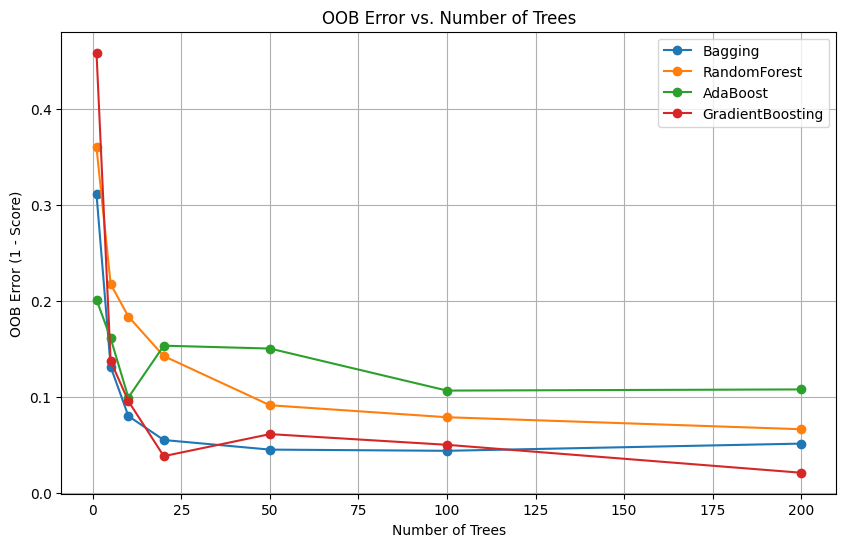

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# We use the same dataset as in Section 4.2 of the Model Testing
np.random.seed(42)
n_samples = 1000
X = np.random.rand(n_samples, 15)
y = np.zeros(n_samples)
y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1
y[(X[:, 2] > 0.7) & (X[:, 3] < 0.5)] = 1
y[(X[:, 4] < 0.2) & (X[:, 5] > 0.8)] = 1
y[(X[:, 6] > 0.6) & (X[:, 7] < 0.4)] = 1
y[(X[:, 8] < 0.1) & (X[:, 9] > 0.9)] = 1
y[np.random.choice(n_samples, size=20, replace=False)] = 1 - y[np.random.choice(n_samples, size=20, replace=False)]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define model
dt_model = DecisionTreeClassifier(random_state=42)

# Test with different numbers of trees
n_trees_range = [1, 5, 10, 20, 50, 100, 200]
oob_errors = {"Bagging": [], "RandomForest": [], "AdaBoost": [], "GradientBoosting": []}

def compute_oob_error(model, X, y):
    n_samples = X.shape[0]
    oob_predictions = np.zeros(n_samples)
    oob_counts = np.zeros(n_samples)

    # Generate bootstrapped training sample indices
    boot_train_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    # Identify out-of-bag (OOB) samples
    oob_mask = np.ones(n_samples, dtype=bool)
    oob_mask[boot_train_indices] = False  # Mark in-bag samples

    # Extract bootstrap sample
    X_boot_train, y_boot_train = X[boot_train_indices], y[boot_train_indices]

    # Fit the model
    model.fit(X_boot_train, y_boot_train)  # Train on bootstrap sample

    # Extract OOB samples
    X_oob, y_oob = X[oob_mask], y[oob_mask]

    if len(y_oob) > 0:
        y_oob_pred = model.predict(X_oob)
        oob_error = 1 - accuracy_score(y_oob, y_oob_pred)  # Compute error
    else:
        oob_error = np.nan  # Handle case where no OOB samples exist

    return oob_error

# Train models and measure OOB error
for n_trees in n_trees_range:
    # Bagging (OOB supported)
    bagging = BaggingClassifier(
        estimator=dt_model,
        n_estimators=n_trees,
        bootstrap=True,
        oob_score=True,
        random_state=42
    )
    bagging.fit(X_train, y_train)
    oob_errors["Bagging"].append(1 - bagging.oob_score_)  # OOB error = 1 - OOB accuracy

    # Random Forest (OOB supported)
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        oob_score=True,
        random_state=42
    )
    rf.fit(X_train, y_train)
    oob_errors["RandomForest"].append(1 - rf.oob_score_)  # OOB error

    # AdaBoost (OOB not supported, using our own function instead)
    ada = AdaBoostClassifier(
        estimator=dt_model,
        n_estimators=n_trees,
        random_state=42
    )
    oob_error_ada = compute_oob_error(ada,X_train,y_train)
    oob_errors["AdaBoost"].append(oob_error_ada)

    # Gradient Boosting (OOB not supported, using our own function)
    gb = ensemble.GradientBoostingClassifier(
        n_estimators=n_trees,
        random_state=42
    )
    gb.fit(X_train, y_train)
    oob_error_gb = compute_oob_error(gb,X_train,y_train)
    oob_errors["GradientBoosting"].append(oob_error_gb)

# Plot the Learning Curves
plt.figure(figsize=(10, 6))
for method, errors in oob_errors.items():
    plt.plot(n_trees_range, errors, label=method, marker='o')

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error (1 - Score)")
plt.title("OOB Error vs. Number of Trees")
plt.legend()
plt.grid()
plt.show()

Bagging: Mean Accuracy = 0.9560 ± 0.0058
RandomForest: Mean Accuracy = 0.9460 ± 0.0086
AdaBoost: Mean Accuracy = 0.9220 ± 0.0103
GradientBoosting: Mean Accuracy = 0.9700 ± 0.0089


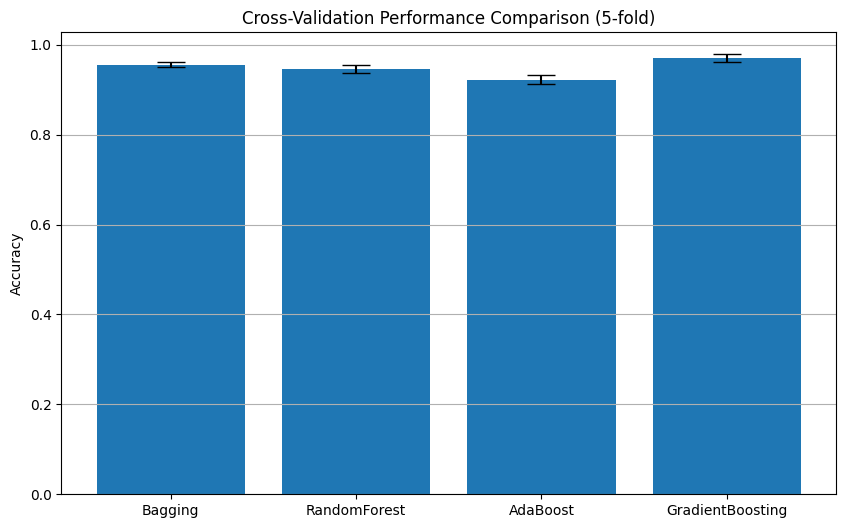

In [ ]:
# Define the final models with optimal number of trees
final_models = {
    "Bagging": BaggingClassifier(estimator=dt_model, n_estimators=50, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=dt_model, n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42)
}

cv_results = {}
for name, model in final_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = {
        'mean_accuracy': np.mean(scores),
        'std_accuracy': np.std(scores)
    }

# Display results
for name, results in cv_results.items():
    print(f"{name}: Mean Accuracy = {results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}")

# Optional: Plot the results for visual comparison
methods = list(cv_results.keys())
means = [cv_results[m]['mean_accuracy'] for m in methods]
stds = [cv_results[m]['std_accuracy'] for m in methods]

plt.figure(figsize=(10, 6))
plt.bar(methods, means, yerr=stds, capsize=10)
plt.ylabel("Accuracy")
plt.title("Cross-Validation Performance Comparison (5-fold)")
plt.grid(True, axis='y')
plt.show()

##Discussion of Results
The comparative analysis of the ensemble methods Bagging, Random Forest, AdaBoost, and Gradient Boosting reveals distinct performance characteristics on the synthetic dataset. Below, we interpret the key findings from the out-of-bag (OOB) error analysis and cross-validation results.

###1. Optimal Number of Trees
When plotting the OOB error against the number of trees, it is evident that the error decreases sharply until the number of 20 trees is reached. Then, it decreases more slowly. We can see an elbow pattern. For some models, the error begins to slightly increase when the number of trees is increased from 100 to 200. Furthermore, we can observe that Gradient Boosting starts with the highest error, but leads to the overall lowest error with 200 trees. This demonstrates that Gradient Boosting profits significantly from a high number of trees. AdaBoost shows a comparatively low error for only one tree, but is surpassed by the other models as soon as more trees are added.

As the optimal number of trees for a model, we should choose the elbow point, where additional trees do not significantly increase performance anymore. This is due to two reasons. Firstly, more trees increase training time and memory usage, so choosing an unnecessarily high number is not efficient. Secondly, Occam's razor states that, among models with similar performance, the simplest one should be preferred to avoid unnecessary complexity and overfitting.

For AdaBoost, the optimal number of trees is 100, for Gradient Boosting 200, and for Bagging as well as the Random Forest 50. This demonstrates how different Ensemble methods need to be tuned differently.

###2. Performance Overview
The cross-validation scores ranked the methods as follows:

Gradient Boosting achieved the highest mean accuracy (0.970 ± 0.0089), demonstrating its effectiveness in modeling complex decision boundaries.

Bagging followed closely (0.956 ± 0.0058), exhibiting the lowest variance, which indicates robust generalization.

Random Forest (0.946 ± 0.0086) underperformed relative to Bagging, contrary to typical expectations.

AdaBoost trailed significantly (0.922 ± 0.0103), suggesting sensitivity to dataset noise or suboptimal hyperparameters.

###3. Key Insights
Gradient Boosting’s Dominance:
The superior performance of Gradient Boosting can be attributed to its sequential error-correction mechanism, which iteratively refines predictions by focusing on residuals. This approach excels in capturing intricate patterns, as evidenced by its 1.4–4.8 percentage-point advantage over other methods. The low standard deviation further confirms its reliability across different data splits.

Bagging’s Consistency:
Bagging’s strong performance and minimal variance (±0.0058) highlight its stability. Unlike Random Forest, which introduces additional randomness through feature subset selection, Bagging relies solely on bootstrap aggregation. This simplicity proved advantageous for the given dataset, where feature interactions might be less critical.

Random Forest’s Unexpected Lag:
Normally, Random Forest outperforms Bagging by reducing correlation between trees via feature randomization. However, if the dataset has a small number of highly informative features, forcing trees to use limited random subsets could weaken performance. Random Forest’s slight underperformance relative to Bagging suggests that, in our dataset with only 9 out of 15 features being informative, the added diversity from random subspaces might have introduced unnecessary noise rather than improved generalization.

AdaBoost’s Limitations:
AdaBoost’s weaker performance and higher variance (±0.0103) indicate susceptibility to label noise (e.g., the 20 intentionally mislabeled samples). Its emphasis on misclassified instances may have led to overfitting, particularly without tuned hyperparameters like learning rate or tree depth.

###4. Method Trade-offs
Each ensemble method presents distinct advantages and limitations. **Gradient Boosting** delivers the highest accuracy but requires careful hyperparameter tuning and significant computational resources to reach its full potential. In contrast, **Bagging** offers a strong balance between performance and stability, making it a reliable choice for scenarios where consistency is a priority. It can, however, be outperformed by other models in many cases. **Random Forest**, while generally robust, may underperform when its feature randomization does not align well with the dataset’s structure, potentially introducing unnecessary variability. Finally, **AdaBoost** tends to be more sensitive to noise and may require additional regularization—such as a lower learning rate—to achieve results comparable to other boosting techniques.

###5. Limitations and Future Work
Regarding the limitations of this work, the synthetic nature of the dataset may favor certain methods. It is very unusual for real datasets to follow the strict hierarchical nature of our dataset. Therefore real-world data could yield different rankings.Secondly, the hyperparameters (e.g., tree depth, learning rates) were not optimized, which might affect the relative performance.

###6. Conclusion about Ensemble Experiments
For this dataset, Gradient Boosting emerges as the top performer, while Bagging provides the most stable predictions. The results underscore the importance of method selection based on data characteristics, with ensemble diversity (e.g., feature vs. instance randomization) playing a critical role in model efficacy. Moreover, the results highlight the importance of choosing the right number of trees and how the optimal number of trees can differ depending on the ensemble method.

# Bibliography
* Blockeel, H., Devos, L., Frénay, B., Nanfack, G., & Nijssen, S. (2023). Decision trees: From efficient prediction to responsible AI. *Frontiers in Artificial Intelligence, 6*, 1124553. https://doi.org/10.3389/frai.2023.1124553
* Cristianini, N., & Shawe-Taylor, J. (2000). *An introduction to support vector machines and other kernel-based learning methods*. Cambridge University Press.
* Differences between LDA, QDA, and Gaussian Naive Bayes classifiers. (n.d.). *Towards Data Science*. Retrieved March 16, 2025, from https://towardsdatascience.com/differences-of-lda-qda-and-gaussian-naive-bayes-classifiers-eaa4
* Eskandar, S. (2023, March 26). Introduction to RBF SVM: A powerful machine learning algorithm for non-linear data. *Medium*. https://medium.com/@eskandar.sahel/introduction-to-rbf-svm-a-powerful-machine-learning-algorithm-for-non-linear-data-1d1cfb55a1a
* James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning: With applications in R*. Springer. https://www.statlearning.com
* Lohweg, V. (2012). *Banknote Authentication* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55P57
* Ng, A. Y., & Jordan, M. I. (2002). On discriminative vs. generative classifiers: A comparison of logistic regression and naive Bayes. *Advances in Neural Information Processing Systems, 14*, 841–848. https://papers.nips.cc/paper_files/paper/2001/file/7b7a53e239400a13bd6be6c91c4f6c4e-Paper.pdf
* Petrik, M. (2017). LDA, QDA, Naive Bayes generative classification models [Lecture notes]. University of New Hampshire. https://www.cs.unh.edu/~mpetrik/teaching/intro_ml_17/intro_ml_17_files/class5.pdf
* Shah, R. (2022, March 30). Supervised ML Algorithm: Support Vector Machines (SVM). *Medium*. https://medium.com/analytics-vidhya/supervised-ml-algorithm-support-vector-machines-svm-fb674430ab74
* Shapiro, A. (1983). *Chess (King-Rook vs. King-Pawn)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DK5C. (cited)
* Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). *Breast Cancer Wisconsin (Diagnostic)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B
* YasserH. (2022). Titanic dataset. Kaggle. Retrieved March 13, 2025, from https://www.kaggle.com/datasets/yasserh/titanic-dataset
* Malato, G. (2024, November 22). Hyperparameter tuning. Grid search and random search | Your Data Teacher. Your Data Teacher. https://www.yourdatateacher.com/2021/05/19/hyperparameter-tuning-grid-search-and-random-search/




# Appendix

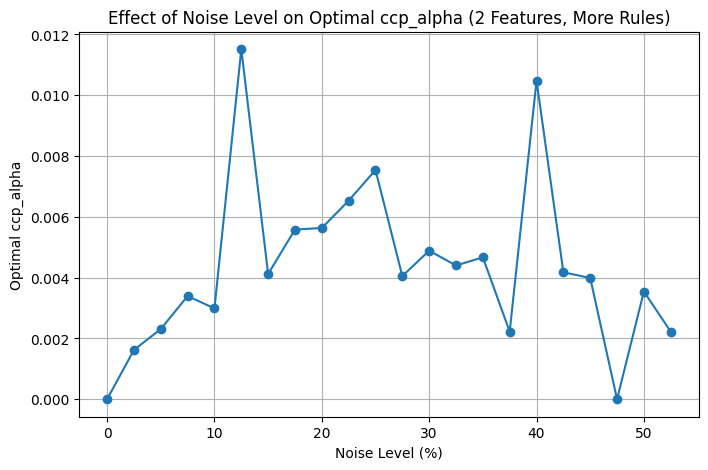

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Set random seed for reproducibility
np.random.seed(42)

# Generate dataset with only 2 features
n_samples = 1000
X = np.random.rand(n_samples, 2)  # Two features only
y = np.zeros(n_samples)

# Define hierarchical rules
y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1
y[(X[:, 0] < 0.4) & (X[:, 1] > 0.7)] = 1
y[(X[:, 0] > 0.8) & (X[:, 1] < 0.2)] = 1
y[(X[:, 0] < 0.2) & (X[:, 1] > 0.9)] = 1
y[(X[:, 0] > 0.6) & (X[:, 1] > 0.5)] = 1

# Define noise levels (0% to 55% in 2.5% steps)
noise_levels = np.arange(0, 0.55, 0.025)
optimal_ccp_alphas = []

for noise in noise_levels:
    y_noisy = y.copy()
    n_noisy_samples = int(noise * n_samples)

    # Flip labels for a percentage of the dataset
    flip_indices = np.random.choice(n_samples, size=n_noisy_samples, replace=False)
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y_noisy, test_size=0.2, random_state=42)

    # Train an unpruned Decision Tree
    tree = DecisionTreeClassifier(random_state=42)
    path = tree.cost_complexity_pruning_path(X_train, y_train)

    # Cross-validation to find optimal ccp_alpha
    ccp_alphas = path.ccp_alphas[:-1]  # Exclude max value (fully pruned tree)
    scores = []

    for alpha in ccp_alphas:
        tree_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        cv_score = np.mean(cross_val_score(tree_pruned, X_train, y_train, cv=5))
        scores.append(cv_score)

    # Select best ccp_alpha
    best_ccp_alpha = ccp_alphas[np.argmax(scores)] if scores else 0
    optimal_ccp_alphas.append(best_ccp_alpha)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(noise_levels * 100, optimal_ccp_alphas, marker='o', linestyle='-')
plt.xlabel("Noise Level (%)")
plt.ylabel("Optimal ccp_alpha")
plt.title("Effect of Noise Level on Optimal ccp_alpha (2 Features, More Rules)")
plt.grid()
plt.show()

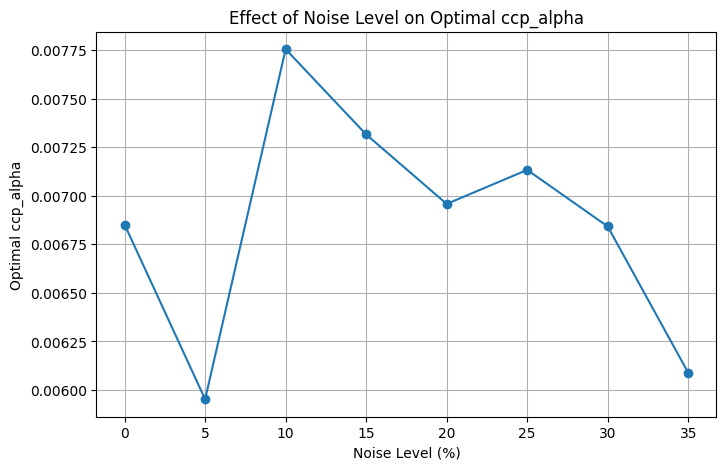

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Set random seed for reproducibility
np.random.seed(42)

# Generate the base dataset
n_samples = 1000
X = np.random.rand(n_samples, 15)
y = np.zeros(n_samples)

# Define hierarchical rules
y[(X[:, 0] > 0.5) & (X[:, 1] < 0.3)] = 1
y[(X[:, 2] > 0.7) & (X[:, 3] < 0.5)] = 1
y[(X[:, 4] < 0.2) & (X[:, 5] > 0.8)] = 1
y[(X[:, 6] > 0.6) & (X[:, 7] < 0.4)] = 1
y[(X[:, 8] < 0.1) & (X[:, 9] > 0.9)] = 1

# Different noise levels
noise_levels = np.arange(0, 0.40, 0.05)  # From 0% to 40% in 5% steps
optimal_ccp_alphas = []

for noise in noise_levels:
    y_noisy = y.copy()
    n_noisy_samples = int(noise * n_samples)

    # Flip labels for a percentage of the dataset
    flip_indices = np.random.choice(n_samples, size=n_noisy_samples, replace=False)
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y_noisy, test_size=0.2, random_state=42)

    # Train an unpruned Decision Tree
    tree = DecisionTreeClassifier(random_state=42)
    path = tree.cost_complexity_pruning_path(X_train, y_train)

    # Cross-validation to find optimal ccp_alpha
    ccp_alphas = path.ccp_alphas
    scores = []

    for alpha in ccp_alphas:
        tree_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        cv_score = np.mean(cross_val_score(tree_pruned, X_train, y_train, cv=5))
        scores.append(cv_score)

    # Select best ccp_alpha
    best_ccp_alpha = ccp_alphas[np.argmax(scores)] if scores else 0
    optimal_ccp_alphas.append(best_ccp_alpha)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(noise_levels * 100, optimal_ccp_alphas, marker='o', linestyle='-')
plt.xlabel("Noise Level (%)")
plt.ylabel("Optimal ccp_alpha")
plt.title("Effect of Noise Level on Optimal ccp_alpha")
plt.grid()
plt.show()

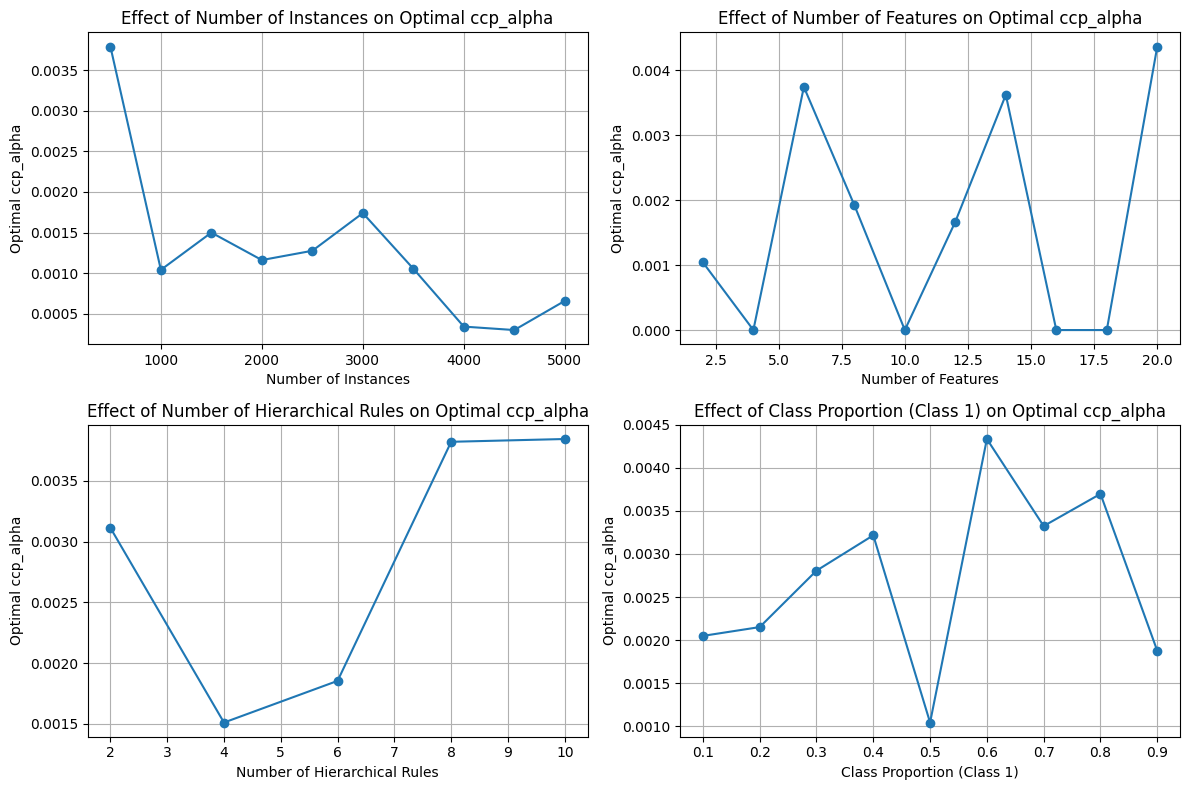

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Function to generate synthetic hierarchical dataset
def generate_dataset(n_samples=1000, n_features=2, n_rules=5, class_ratio=0.5):
    np.random.seed(42)
    X = np.random.rand(n_samples, n_features)
    y = np.zeros(n_samples)

    # Generate hierarchical rules
    for i in range(n_rules):
        idx1, idx2 = np.random.choice(n_features, 2, replace=False)
        threshold1, threshold2 = np.random.rand(), np.random.rand()
        y[(X[:, idx1] > threshold1) & (X[:, idx2] < threshold2)] = 1

    # Adjust class ratio
    n_class_1 = int(n_samples * class_ratio)
    class_1_indices = np.random.choice(n_samples, size=n_class_1, replace=False)
    y[:] = 0
    y[class_1_indices] = 1

    return X, y

# Function to find optimal ccp_alpha
def find_optimal_ccp_alpha(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    tree = DecisionTreeClassifier(random_state=42)
    path = tree.cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas[:-1]  # Exclude max alpha (fully pruned tree)

    scores = []
    for alpha in ccp_alphas:
        tree_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        cv_score = np.mean(cross_val_score(tree_pruned, X_train, y_train, cv=5))
        scores.append(cv_score)

    return ccp_alphas[np.argmax(scores)] if scores else 0

# Vary different dataset properties
property_ranges = {
    "Number of Instances": np.arange(500, 5001, 500),
    "Number of Features": np.arange(2, 21, 2),
    "Number of Hierarchical Rules": np.arange(2, 11, 2),
    "Class Proportion (Class 1)": np.linspace(0.1, 0.9, 9),
}

optimal_ccp_results = {}

for prop, values in property_ranges.items():
    optimal_ccp_alphas = []

    for value in values:
        if prop == "Number of Instances":
            X, y = generate_dataset(n_samples=value)
        elif prop == "Number of Features":
            X, y = generate_dataset(n_features=value)
        elif prop == "Number of Hierarchical Rules":
            X, y = generate_dataset(n_rules=value)
        elif prop == "Class Proportion (Class 1)":
            X, y = generate_dataset(class_ratio=value)

        optimal_ccp_alphas.append(find_optimal_ccp_alpha(X, y))

    optimal_ccp_results[prop] = (values, optimal_ccp_alphas)

# Plot results
plt.figure(figsize=(12, 8))
for i, (prop, (x_values, y_values)) in enumerate(optimal_ccp_results.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(x_values, y_values, marker='o', linestyle='-')
    plt.xlabel(prop)
    plt.ylabel("Optimal ccp_alpha")
    plt.title(f"Effect of {prop} on Optimal ccp_alpha")
    plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate bias, variance and total error
def calculate_bias_variance(X_train, y_train, X_test, y_test, ccp_alpha, n_splits=5):
    tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Use StratifiedKFold to ensure consistent class distribution in each fold
    skf = StratifiedKFold(n_splits=n_splits)

    # Store predictions for each fold
    model_preds = np.zeros((n_splits, len(y_test)))

    # Perform cross-validation
    fold = 0
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Train the model on the current fold's training data
        tree.fit(X_train_fold, y_train_fold)

        # Predict on the test set for this fold
        model_preds[fold, :] = tree.predict(X_test)
        fold += 1

    # Bias: squared difference between predicted mean and true values
    bias = np.mean((model_preds.mean(axis=0) - y_test) ** 2)

    # Variance: variance of predictions across folds for each point
    variance = np.var(model_preds, axis=0).mean()

    # Total error (bias + variance)
    total_error = bias + variance

    return bias, variance, total_error

# Use optimal ccp_alpha from Task 1
# Store the optimal ccp_alpha values you found in Task 1 for each number of instances
optimal_ccp_alphas_2 = {
    500: optimal_ccp_alphas[0],
    2500: optimal_ccp_alphas[4],
    5000: optimal_ccp_alphas[-1]
}

# Varying the number of instances
n_samples_values = [500, 2500, 5000]
ccp_alpha_values = [optimal_ccp_alphas_2[n] for n in n_samples_values]

bias_results = {}
variance_results = {}
total_error_results = {}

for n_samples, ccp_alpha in zip(n_samples_values, ccp_alpha_values):
    X, y = generate_hierarchical_dataset(n_samples=n_samples)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    bias_list = []
    variance_list = []
    total_error_list = []

    # Compute bias, variance, and total error for the optimal ccp_alpha
    bias, variance, total_error = calculate_bias_variance(X_train, y_train, X_test, y_test, ccp_alpha)
    bias_list.append(bias)
    variance_list.append(variance)
    total_error_list.append(total_error)

    # Store results for plotting
    bias_results[n_samples] = bias_list
    variance_results[n_samples] = variance_list
    total_error_results[n_samples] = total_error_list

# Create a dictionary to store the results
summary_data = {
    "Number of Instances": n_samples_values,
    "Optimal ccp_alpha": [optimal_ccp_alphas_2[n] for n in n_samples_values],
    "Bias": [bias_results[n] for n in n_samples_values],
    "Variance": [variance_results[n] for n in n_samples_values],
    "Total Error": [total_error_results[n] for n in n_samples_values],
}

# Convert to a DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the table
print(summary_df)

   Number of Instances  Optimal ccp_alpha                    Bias  \
0                  500           0.014881                 [0.162]   
1                 2500           0.001688  [0.027600000000000003]   
2                 5000           0.000752               [0.01068]   

                 Variance             Total Error  
0   [0.04000000000000001]                 [0.202]  
1  [0.015200000000000003]  [0.042800000000000005]  
2               [0.00872]                [0.0194]  


#Declaration of AI and AI-assisted technologies in the writing process
During the preparation of this work the authors
used Large Language Models (e.g., OpenAI’s GPT-4o, Anthropic’s Claude 3.5 Sonnet etc) in order to improve readability and language. After using these tools, the authors reviewed and edited the content as needed and take full responsibility for the content of the work.